# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [145]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


In [146]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Sampling techniques
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# XGBoost
from xgboost import XGBClassifier

# Metrics
from sklearn import metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Observations

The following libraries were imported for:

- Data manipulation and analysis (NumPy, Pandas)
- Data visualization (Matplotlib, Seaborn)
- Data preprocessing and sampling (SMOTE, RandomUnderSampler)
- Model building (Decision Tree, Random Forest, Bagging, AdaBoost, Gradient Boosting, XGBoost)
- Hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
- Model evaluation (Accuracy, Precision, Recall, F1-score, ROC-AUC)

# **Loading the dataset**

In [147]:
from google.colab import drive
drive.mount('/content/drive')

visa = pd.read_csv("/content/drive/MyDrive/AIML-UTA-PY/EasyVisa.csv")
data = visa.copy()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Overview of the Dataset**

In [148]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Observation**
The dataset loads successfully and displays the first 5 rows.

In [149]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


**Observation**
The dataset loads successfully and displays the last 5 rows.

In [150]:
# Basic structure of the dataset
print("Shape:", data.shape)

# Data types and non-null counts
data.info()

Shape: (25480, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [151]:
# Missing value check
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [152]:
# Duplicate row check
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [153]:
# Unique values in each column
print("Unique Values:")
print(data.nunique())

Unique Values:
case_id                  25480
continent                    6
education_of_employee        4
has_job_experience           2
requires_job_training        2
no_of_employees           7105
yr_of_estab                199
region_of_employment         5
prevailing_wage          25454
unit_of_wage                 4
full_time_position           2
case_status                  2
dtype: int64


In [154]:
# Target variable distribution
print("Case Status Distribution:")
print(data["case_status"].value_counts())

print("\nCase Status Percentage:")
print(round(data["case_status"].value_counts(normalize=True) * 100, 2))

Case Status Distribution:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Case Status Percentage:
case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64


In [155]:
# Summary statistics
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [156]:
# Check negative values in no_of_employees
neg_count = (data["no_of_employees"] < 0).sum()
print("Negative no_of_employees rows:", neg_count)

Negative no_of_employees rows: 33


In [157]:
# Summary statistics
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
# Correct invalid employee counts
data["no_of_employees"] = data["no_of_employees"].abs()

# Verify correction
print(
    "Negative no_of_employees rows after correction:",
    (data["no_of_employees"] < 0).sum()
)

Negative no_of_employees rows after correction: 0




## Overview of the Dataset

### Overview

- The dataset contains **25,480 records and 12 variables**.
- The target variable is **case_status**, which indicates whether a visa application was **Certified** or **Denied**.
- The dataset consists of **9 categorical variables** and **3 numerical variables**.
- All variables contain **25,480 non-null values**, indicating that there are **no missing values** in the dataset.
- No duplicate records were found in the dataset.
- The variable **case_id** contains **25,480 unique values**, confirming that each visa application has a unique identifier.
- Approximately **66.79%** of visa applications were Certified, while **33.21%** were Denied, indicating a moderate class imbalance.
- The dataset appears clean overall and suitable for exploratory data analysis and predictive modeling.

### Sanity Checks

- Verified dataset dimensions using `shape()`.
- Reviewed data types and non-null counts using `info()`.
- Checked for missing values across all variables and found none.
- Checked for duplicate records and found 0 duplicates.
- Verified the target variable classes and their distribution.
- Checked the number of unique values in each variable.
- Identified 33 records with negative values in `no_of_employees`, which are not logically valid and require correction before model building.

### Observations from Summary Statistics

- The average employer size is approximately **5,667 employees**, although there is substantial variation across employers.
- The oldest company in the dataset was established in **1800**, while the newest companies were established in **2016**.
- The median prevailing wage is approximately **$70,308**, with wages ranging from **$2.14** to over **$319,000**, indicating considerable variability.
- The variables **no_of_employees** and **prevailing_wage** appear to contain extreme values and will be examined further during exploratory data analysis.
- A small number of invalid negative employee counts were detected and corrected during data preprocessing.

### Implications for Further Analysis

- The variable **case_id** serves as a unique identifier and will be removed during data preprocessing as it does not contribute to prediction.
- Since no missing values are present in the dataset, missing value imputation will not be required.
- The variable **no_of_employees** contained 33 invalid negative values, which were corrected during data preprocessing.
- Numerical variables such as **prevailing_wage**, **no_of_employees**, and **yr_of_estab** will be further examined for distribution, skewness, and potential outliers.
- Categorical variables such as **continent**, **education_of_employee**, **has_job_experience**, **region_of_employment**, and **unit_of_wage** may influence visa certification outcomes and will be explored in greater detail during EDA.
- The moderate class imbalance observed in the target variable suggests that model performance should be evaluated using metrics such as Precision, Recall, and F1-score, in addition to Accuracy.
- To assess the impact of class imbalance, models will be developed using the original data, oversampled data (SMOTE), and undersampled data.

### Business Insight

The dataset contains a combination of applicant-related and employer-related attributes that can help identify the factors influencing visa certification decisions. By analyzing these variables and building predictive models, EasyVisa can streamline the visa screening process, prioritize applications with a higher likelihood of approval, and improve overall decision-making efficiency.

# **Exploratory Data Analysis (EDA)**

In [159]:
data.describe(include="all")

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480.000000,25480.000000,25480,25480.000000,25480,25480,25480
unique,25480,6,4,2,2,NaN,NaN,5,NaN,4,2,2
top,EZYV25480,Asia,Bachelor's,Y,N,NaN,NaN,Northeast,NaN,Year,Y,Certified
freq,1,16861,10234,14802,22525,NaN,NaN,7195,NaN,22962,22773,17018
mean,NaN,NaN,NaN,NaN,NaN,5667.089207,1979.409929,NaN,74455.814592,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22877.917453,42.366929,NaN,52815.942327,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,11.000000,1800.000000,NaN,2.136700,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1022.000000,1976.000000,NaN,34015.480000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2109.000000,1997.000000,NaN,70308.210000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3504.000000,2005.000000,NaN,107735.512500,NaN,NaN,NaN


## Observations from Summary Statistics

### Categorical Variables

- The dataset contains applicants from **6 continents**, with **Asia** being the most represented continent (16,861 applications).
- There are **4 education levels** represented in the dataset, with **Bachelor's degree holders** forming the largest group (10,234 applications).
- A majority of applicants have prior job experience, as indicated by the higher frequency of "Y" in the `has_job_experience` variable (14,802 applications).
- Most applicants do not require job training, with **22,525 applications** indicating "No" for `requires_job_training`.
- Applications are distributed across **5 employment regions**, with the **Northeast** region accounting for the highest number of applications (7,195).
- Most positions offer wages on a **yearly basis**, with **22,962 applications** reporting yearly wages.
- The majority of positions are **full-time positions**, accounting for **22,773 applications**.
- Visa certifications outnumber denials, with **17,018 Certified applications** compared to **8,462 Denied applications**.

### Numerical Variables

- The average employer size is approximately **5,667 employees**, while the median employer size is **2,109 employees**, indicating a right-skewed distribution.
- Employer sizes range from **11 employees to 602,069 employees**, suggesting the presence of large organizations and potential outliers.
- Employer establishment years range from **1800 to 2016**, indicating a mix of long-established and relatively new companies.
- The median prevailing wage is approximately **$70,308**, while wages range from **$2.14 to $319,210**, showing substantial variability across job positions.
- The large difference between the minimum and maximum values of `no_of_employees` and `prevailing_wage` suggests potential outliers that should be investigated further using boxplots and distribution plots.
- The standard deviation of prevailing wage (**$52,816**) is relatively high, indicating considerable wage dispersion among applicants.

### Initial Insights

- Education level, prior job experience, wage structure, employment region, and company characteristics may play an important role in determining visa certification outcomes.
- The prevalence of yearly wages and full-time positions suggests that most visa applications are associated with long-term employment opportunities.
- Further exploratory analysis is required to understand how these variables influence visa approval decisions.

### Data Quality Treatment

During the initial data quality assessment, 33 records were identified with negative values in `no_of_employees`. Since the number of employees cannot be negative, these values were converted to their absolute values before further analysis and model building.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

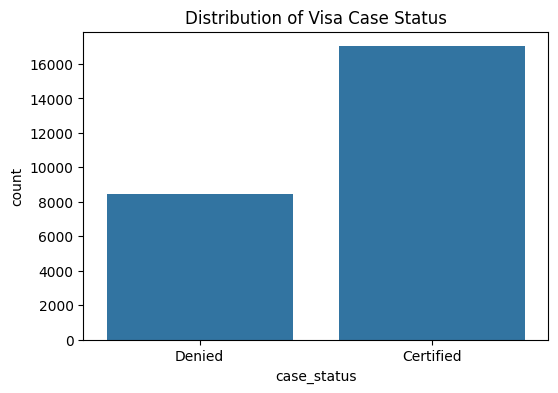

case_status
Certified    66.79
Denied       33.21
Name: proportion, dtype: float64


In [160]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='case_status')
plt.title('Distribution of Visa Case Status')
plt.show()

print(round(data['case_status'].value_counts(normalize=True)*100,2))

### Observations

- The majority of visa applications were **Certified (66.79%)**, while **33.21%** were Denied.
- Certified applications outnumber denied applications by approximately **2:1**.
- The target variable exhibits a **moderate class imbalance**, which may influence model performance.
- Accuracy alone may not be sufficient for evaluating classification models; therefore, metrics such as Precision, Recall, and F1-score will also be considered.
- To assess the impact of class imbalance, models will be developed using the original dataset, oversampled data (SMOTE), and undersampled data.

### Business Insight

- Historically, most visa applications in the dataset have been approved, indicating that certification is more common than denial.
- Understanding the factors that differentiate certified and denied applications can help EasyVisa prioritize cases and improve decision-making efficiency.

# Univariate Analysis

## Univariate Analysis of Categorical Variables

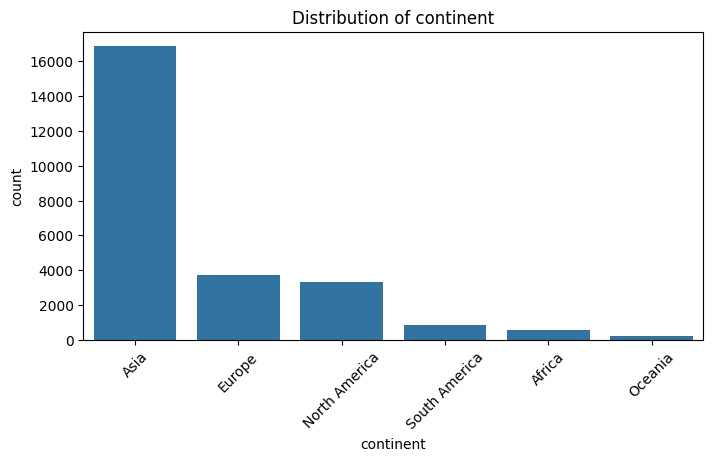

continent
Asia             66.17
Europe           14.65
North America    12.92
South America     3.34
Africa            2.16
Oceania           0.75
Name: proportion, dtype: float64
------------------------------------------------------------


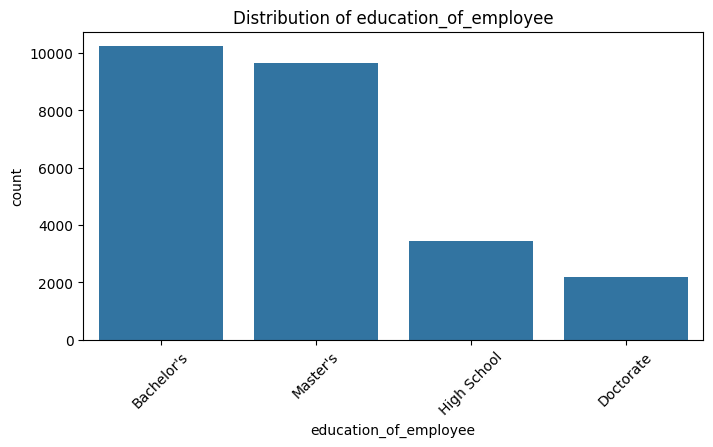

education_of_employee
Bachelor's     40.16
Master's       37.81
High School    13.42
Doctorate       8.60
Name: proportion, dtype: float64
------------------------------------------------------------


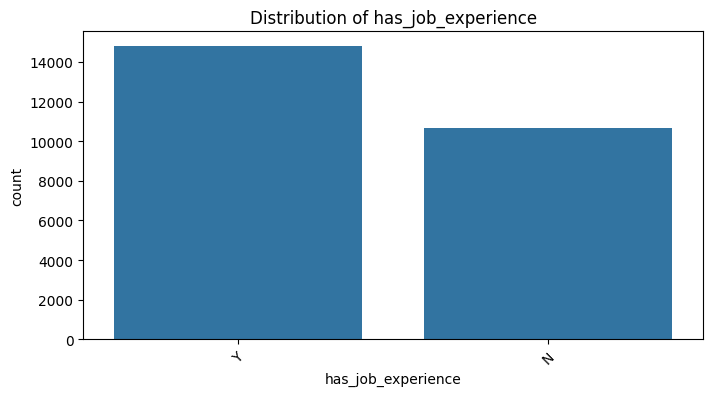

has_job_experience
Y    58.09
N    41.91
Name: proportion, dtype: float64
------------------------------------------------------------


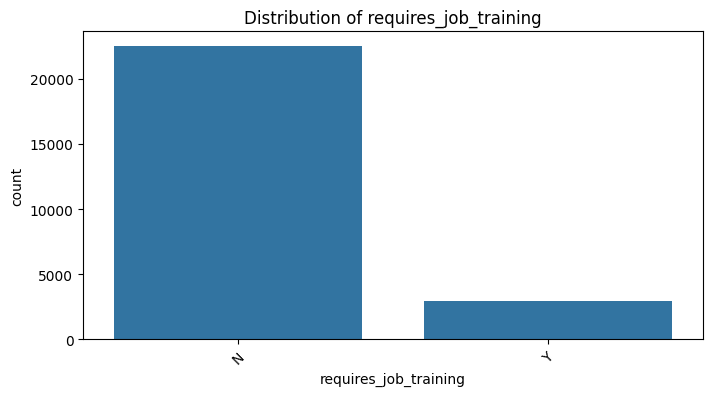

requires_job_training
N    88.4
Y    11.6
Name: proportion, dtype: float64
------------------------------------------------------------


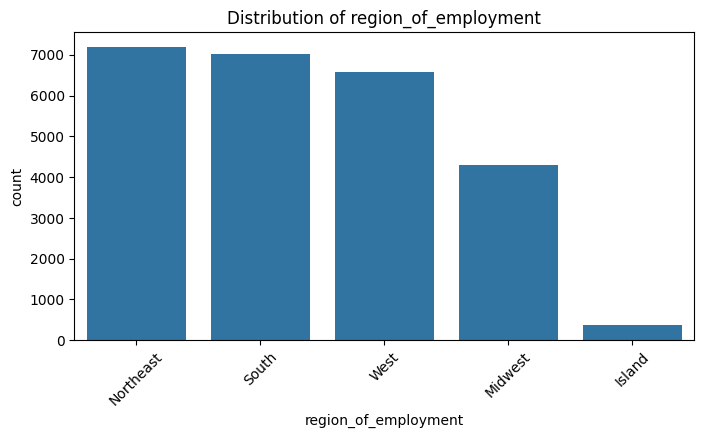

region_of_employment
Northeast    28.24
South        27.54
West         25.85
Midwest      16.90
Island        1.47
Name: proportion, dtype: float64
------------------------------------------------------------


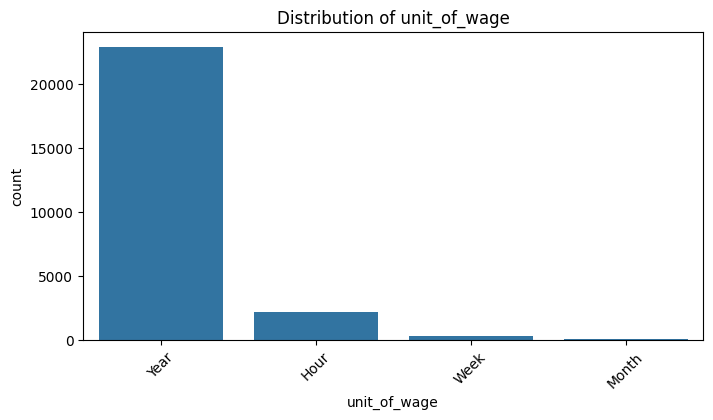

unit_of_wage
Year     90.12
Hour      8.47
Week      1.07
Month     0.35
Name: proportion, dtype: float64
------------------------------------------------------------


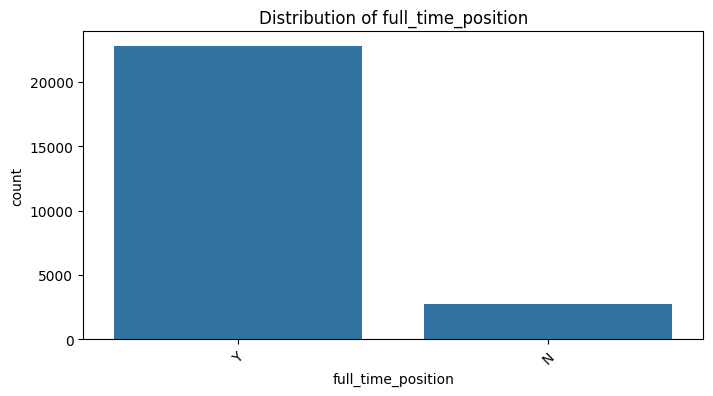

full_time_position
Y    89.38
N    10.62
Name: proportion, dtype: float64
------------------------------------------------------------


In [161]:
# List of categorical variables
categorical_cols = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'unit_of_wage',
    'full_time_position'
]

# Plot distribution of each categorical variable
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

    # Display percentage distribution
    print(data[col].value_counts(normalize=True).mul(100).round(2))
    print("-"*60)

## Observations - Categorical Variables

### Continent

- Applicants from **Asia** account for the majority of visa applications (**66.17%**), making it the most represented continent in the dataset.
- Europe (**14.65%**) and North America (**12.92%**) contribute a moderate share of applications.
- South America (**3.34%**), Africa (**2.16%**), and Oceania (**0.75%**) account for a relatively small proportion of applications.

### Education Level

- **Bachelor's degree holders** represent the largest applicant group (**40.16%**), closely followed by **Master's degree holders** (**37.81%**).
- Applicants with a **High School education** account for **13.42%** of applications.
- **Doctorate holders** represent the smallest education category (**8.60%**).
- More than three-quarters of applicants possess at least a Bachelor's degree, indicating a highly educated applicant pool.

### Job Experience

- A majority of applicants (**58.09%**) have prior job experience.
- Applicants without prior job experience account for **41.91%** of the dataset.
- This suggests that work experience may be an important factor influencing visa certification decisions.

### Job Training Requirement

- Most applicants (**88.40%**) do not require additional job training.
- Only **11.60%** of applicants require job training.
- This indicates that the majority of applicants are already considered job-ready.

### Region of Employment

- The **Northeast (28.24%)** has the highest concentration of visa applications.
- The **South (27.54%)** and **West (25.85%)** regions also account for a significant share of applications.
- The **Midwest (16.90%)** contributes a moderate number of applications.
- The **Island region (1.47%)** has the lowest number of applications.

### Unit of Wage

- Most positions (**90.12%**) report wages on a **yearly basis**.
- Hourly wages account for **8.47%** of applications.
- Weekly (**1.07%**) and monthly (**0.35%**) wage structures are relatively uncommon.
- The dominance of yearly wages suggests that most applications are associated with long-term employment opportunities.

### Full-Time Position

- The majority of applications (**89.38%**) are for **full-time positions**.
- Only **10.62%** of applications correspond to part-time positions.
- This indicates that foreign labor certifications are primarily sought for full-time employment.

## Key Insights

- The applicant pool is heavily concentrated in Asia and consists predominantly of highly educated individuals.
- Most applicants possess prior work experience and do not require additional job training.
- Visa applications are primarily associated with full-time positions offering yearly wages.
- The Northeast, South, and West regions account for the majority of employment opportunities.
- Several categorical variables exhibit highly imbalanced distributions, suggesting they may play an important role in explaining visa certification outcomes and should be explored further through bivariate analysis.

## Univariate Analysis of Numerical Variables

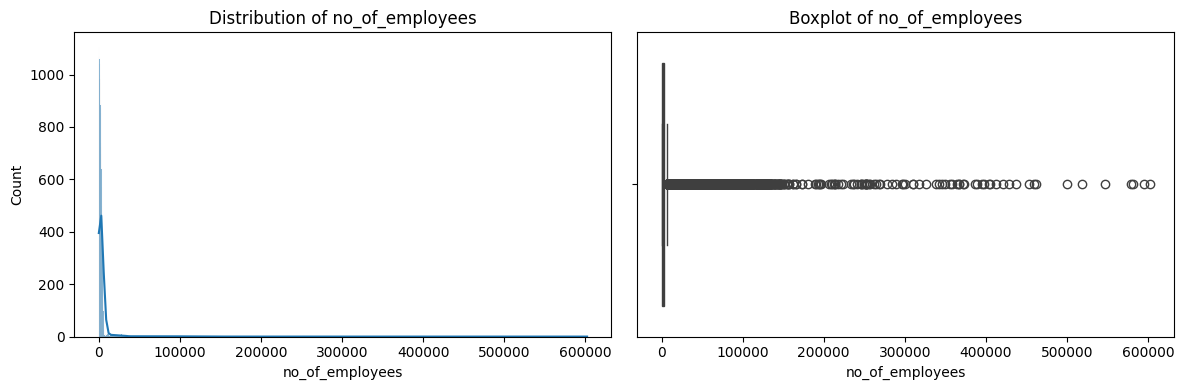

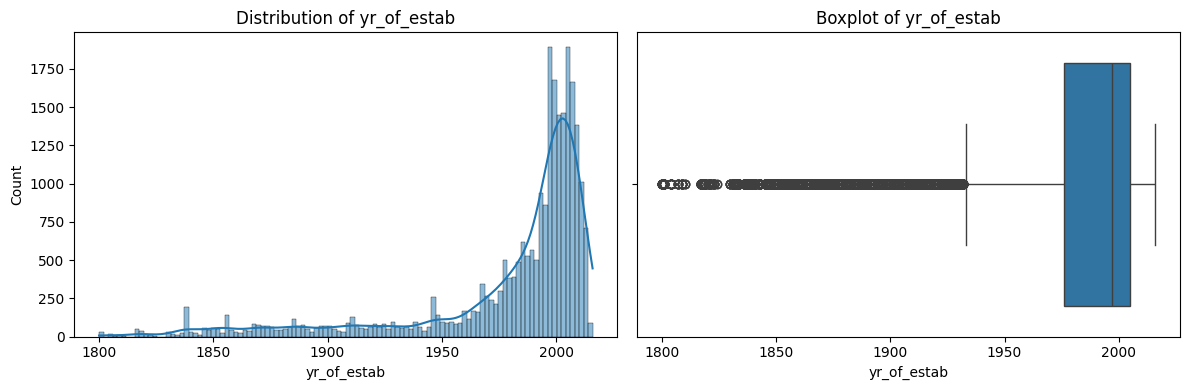

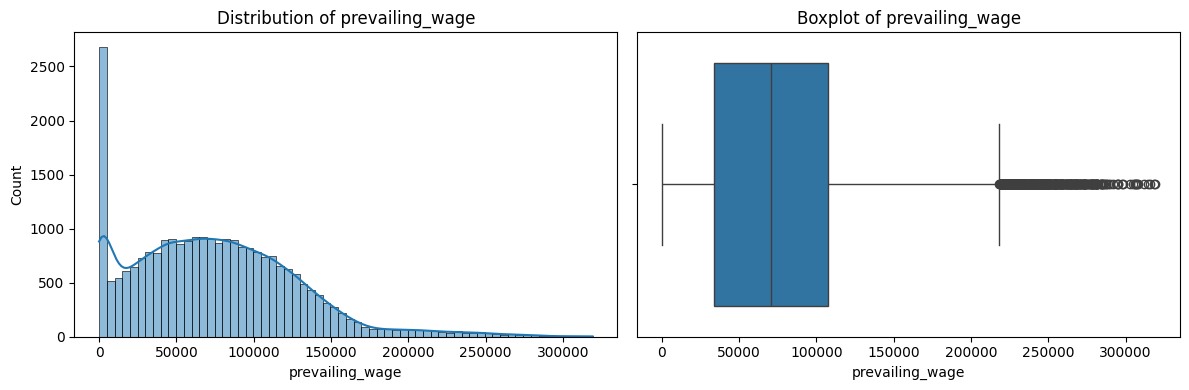

In [162]:
# Numerical variables
numerical_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in numerical_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribution plot
    sns.histplot(data=data, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=data[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [163]:
# Skewness of numerical variables
data[['no_of_employees', 'yr_of_estab', 'prevailing_wage']].skew()

,0
no_of_employees,12.265273
yr_of_estab,-2.037301
prevailing_wage,0.755776


## Observations - Numerical Variables

### Number of Employees (no_of_employees)

- Most employers in the dataset have a relatively small workforce, while a few companies employ a very large number of employees.
- The distribution is heavily right-skewed, indicating that large employers are much less common than small and medium-sized employers.
- The boxplot shows several extreme values, suggesting the presence of outliers.
- These large values are likely to represent genuine company sizes rather than data errors and will be retained for further analysis.

### Year of Establishment (yr_of_estab)

- Most employers were established in recent decades, particularly after 1980.
- Only a small number of companies were founded before 1950.
- The distribution is left-skewed because older companies are relatively rare compared to newer organizations.
- The presence of both newly established and long-standing companies may provide useful insights into visa certification outcomes.

### Prevailing Wage (prevailing_wage)

- Prevailing wages vary considerably across applications.
- Most wages fall below $150,000, although a small number of positions offer significantly higher wages.
- The boxplot indicates the presence of some high-wage outliers.
- Wage levels may be an important factor influencing visa approval decisions and will be explored further in the bivariate analysis.

### Overall Insights

- Both no_of_employees and prevailing_wage contain a number of extreme values.
- These values appear to be valid observations rather than data quality issues.
- Since the models used in this project are primarily tree-based algorithms, outlier treatment is not expected to have a significant impact on model performance.
- Therefore, the outliers will be retained for further analysis and model building.

### Outlier Treatment

Boxplots identified outliers in both `no_of_employees` and `prevailing_wage`. However, these values appear to represent legitimate business observations rather than data quality issues. Since the primary models used in this project are tree-based algorithms, which are relatively robust to outliers, no outlier treatment was performed.

# Bivariate Analysis

## Continent vs Case Status

In [164]:
# Continent vs visa certification status

continent_status = pd.crosstab(
    data["continent"],
    data["case_status"],
    normalize="index"
) * 100

continent_status

case_status,Certified,Denied
continent,,
Africa,72.050817,27.949183
Asia,65.310480,34.689520
Europe,79.233655,20.766345
North America,61.877278,38.122722
Oceania,63.541667,36.458333
South America,57.863850,42.136150


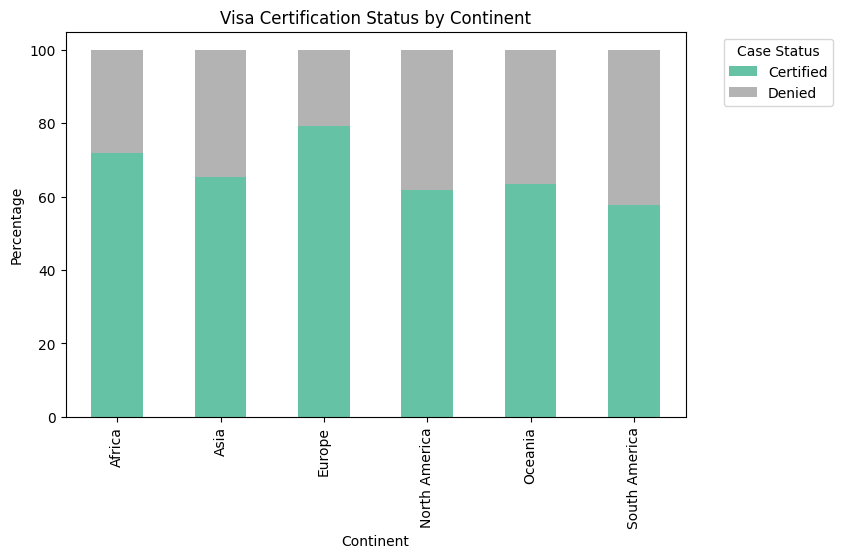

In [165]:
# Visualization of continent vs visa certification status

continent_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Continent")
plt.ylabel("Percentage")
plt.xlabel("Continent")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates differ noticeably across continents.
- **Europe** has the highest certification rate, with approximately **79.2%** of applications being certified and only **20.8%** denied.
- **Africa** also shows a relatively high certification rate of **72.1%**.
- Applicants from **Asia**, which represents the majority of applications in the dataset, have a certification rate of approximately **65.3%**.
- **North America** and **Oceania** show similar certification rates of around **62%–64%**.
- **South America** has the lowest certification rate (**57.9%**) and the highest denial rate (**42.1%**) among all continents.
- The difference between the highest certification rate (Europe: 79.2%) and the lowest certification rate (South America: 57.9%) is more than 21 percentage points, suggesting that continent may be an important factor associated with visa certification outcomes.

### Business Insight

- Applicants from Europe and Africa appear to have a higher likelihood of visa certification compared to applicants from other continents.
- Since Asia contributes the largest number of applications, even small changes in certification rates within this group could have a significant impact on overall visa approval volumes.
- The observed differences across continents suggest that geographic factors may influence certification outcomes and should be considered during model development.

## Education Level vs Case Status

In [166]:
# Education level vs visa certification status

education_status = pd.crosstab(
    data["education_of_employee"],
    data["case_status"],
    normalize="index"
) * 100

education_status.round(2)

case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.21,37.79
Doctorate,87.23,12.77
High School,34.04,65.96
Master's,78.63,21.37


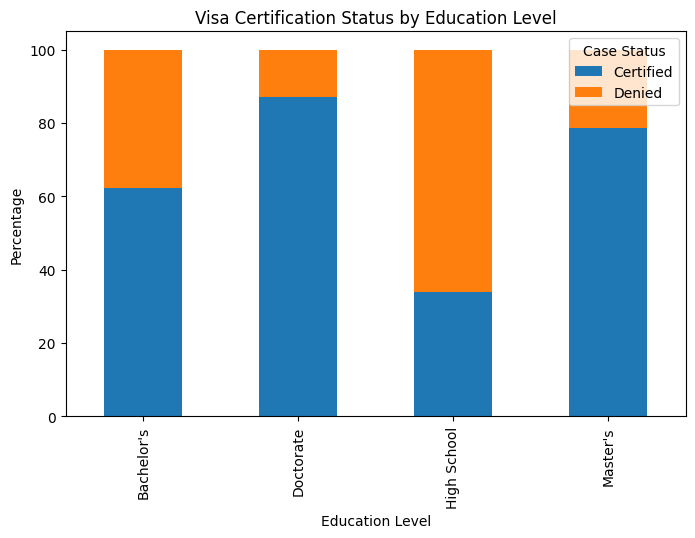

In [167]:
# Visualization of education level vs visa certification status

education_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Visa Certification Status by Education Level")
plt.ylabel("Percentage")
plt.xlabel("Education Level")
plt.legend(title="Case Status")
plt.show()

## Education Level vs Visa Certification Status

### Observations

- Education level appears to have a strong association with visa certification outcomes.
- Applicants with a **Doctorate** have the highest certification rate, with approximately **87.2%** of applications being certified.
- Applicants with a **Master's degree** also show a high certification rate of **78.6%**.
- **Bachelor's degree holders** have a certification rate of approximately **62.2%**.
- Applicants with only a **High School education** have the lowest certification rate (**34.0%**) and the highest denial rate (**66.0%**).
- A clear upward trend can be observed, where visa certification rates generally increase with higher levels of education.
- The difference between Doctorate holders (87.2%) and High School graduates (34.0%) is more than 50 percentage points, indicating a substantial impact of educational qualifications on visa outcomes.

### Business Insight

- Higher educational qualifications appear to significantly improve the likelihood of visa certification.
- Employers and applicants with advanced degrees may have a competitive advantage during the certification process.
- Education level is likely to be one of the most influential predictors in the final machine learning model.

## Job Experience vs Visa Certification Status

In [168]:
# Job experience vs visa certification status

experience_status = pd.crosstab(
    data["has_job_experience"],
    data["case_status"],
    normalize="index"
) * 100

experience_status.round(2)

case_status,Certified,Denied
has_job_experience,,
N,56.13,43.87
Y,74.48,25.52


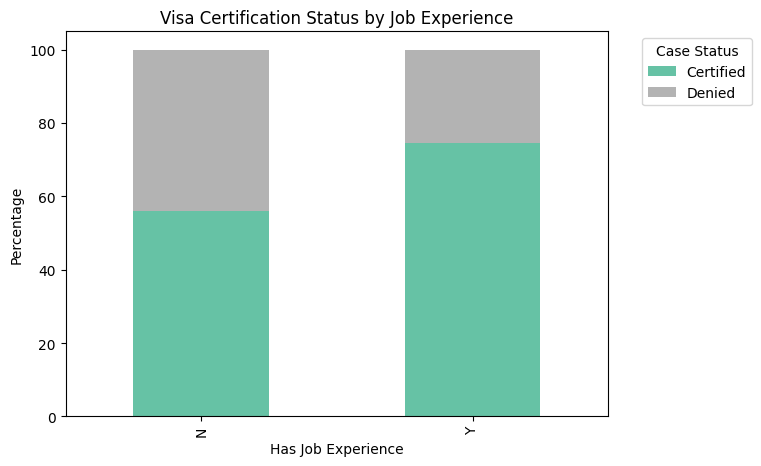

In [169]:
# Visualization of job experience vs visa certification status

experience_status.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Job Experience")
plt.ylabel("Percentage")
plt.xlabel("Has Job Experience")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Applicants with prior job experience have a noticeably higher visa certification rate than applicants without prior experience.
- Approximately three-quarters of applicants with job experience are certified, whereas the certification rate is considerably lower for applicants without experience.
- Applicants without prior job experience show a substantially higher denial rate.
- The difference in certification rates between the two groups suggests that work experience is an important factor in visa certification decisions.
- The relationship between job experience and certification appears stronger than the relationship observed for some of the other categorical variables analyzed so far.

### Business Insight

- Prior job experience appears to improve the likelihood of visa certification.
- Employers may place greater value on candidates who already possess relevant work experience, reducing the need for additional training and onboarding.
- Job experience is likely to be an important predictor in the final machine learning model.

## Job Training Requirement vs Visa Certification Status

In [170]:
# Job training requirement vs visa certification status

training_status = pd.crosstab(
    data["requires_job_training"],
    data["case_status"],
    normalize="index"
) * 100

training_status.round(2)

case_status,Certified,Denied
requires_job_training,,
N,66.65,33.35
Y,67.88,32.12


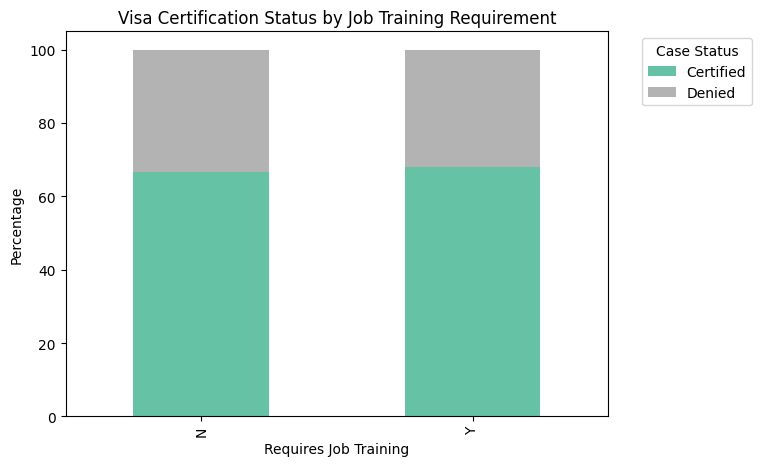

In [171]:
# Visualization of job training requirement vs visa certification status

training_status.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Job Training Requirement")
plt.ylabel("Percentage")
plt.xlabel("Requires Job Training")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates are very similar for applicants who require job training and those who do not.
- Applicants requiring job training have a certification rate of **67.88%**, while applicants not requiring training have a certification rate of **66.65%**.
- The difference in approval rates between the two groups is relatively small, at approximately **1 percentage point**.
- The stacked bar chart shows nearly identical distributions of certified and denied applications for both categories.
- Based on the available data, job training requirement does not appear to have a strong influence on visa certification outcomes.

### Business Insight

- Whether an applicant requires job training does not appear to significantly affect the likelihood of visa certification.
- Compared with factors such as education level and prior job experience, job training requirement is likely to be a weaker predictor of visa approval.
- This variable may contribute limited predictive power to the final machine learning model.

## Region of Employment vs Visa Certification Status

In [172]:
# Region of employment vs visa certification status

region_status = pd.crosstab(
    data["region_of_employment"],
    data["case_status"],
    normalize="index"
) * 100

region_status.round(2)

case_status,Certified,Denied
region_of_employment,,
Island,60.27,39.73
Midwest,75.53,24.47
Northeast,62.90,37.10
South,70.02,29.98
West,62.25,37.75


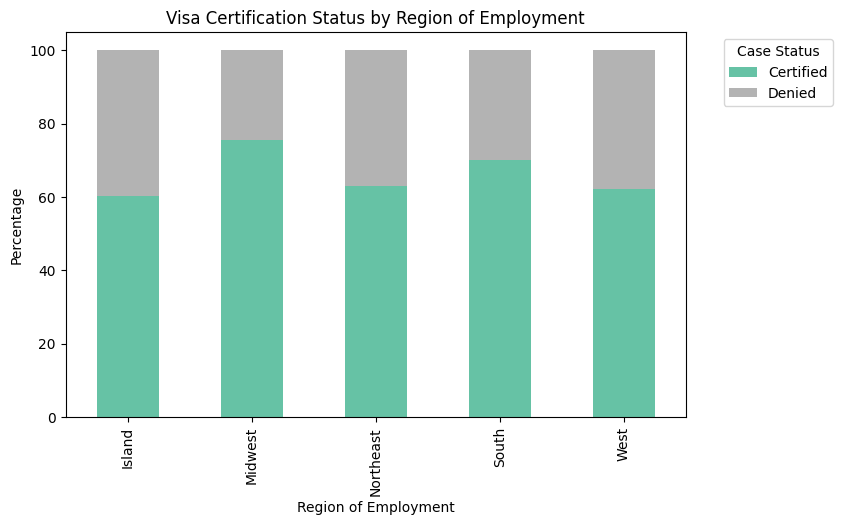

In [173]:
# Visualization of region of employment vs visa certification status

region_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Region of Employment")
plt.ylabel("Percentage")
plt.xlabel("Region of Employment")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates vary across different regions of employment.
- The **Midwest** has the highest certification rate, with approximately **75.5%** of applications being certified.
- The **South** also shows a relatively high certification rate of **70.0%**.
- The **Northeast** and **West** regions have similar certification rates of around **62%–63%**.
- The **Island** region has the lowest certification rate (**60.3%**) and the highest denial rate (**39.7%**).
- The difference between the highest certification rate (Midwest: 75.5%) and the lowest certification rate (Island: 60.3%) is approximately **15 percentage points**.
- These results suggest that the intended region of employment may be associated with visa certification outcomes.

### Business Insight

- Applications for positions located in the Midwest and South appear to have a higher likelihood of certification compared to other regions.
- Regional labor market conditions and workforce demand may contribute to the differences observed in certification rates.
- Although the relationship is not as strong as education level, region of employment may still provide useful predictive information for the machine learning models.

## Unit of Wage vs Visa Certification Status

In [174]:
# Unit of wage vs visa certification status

wage_unit_status = pd.crosstab(
    data["unit_of_wage"],
    data["case_status"],
    normalize="index"
) * 100

wage_unit_status.round(2)

case_status,Certified,Denied
unit_of_wage,,
Hour,34.63,65.37
Month,61.80,38.20
Week,62.13,37.87
Year,69.89,30.11


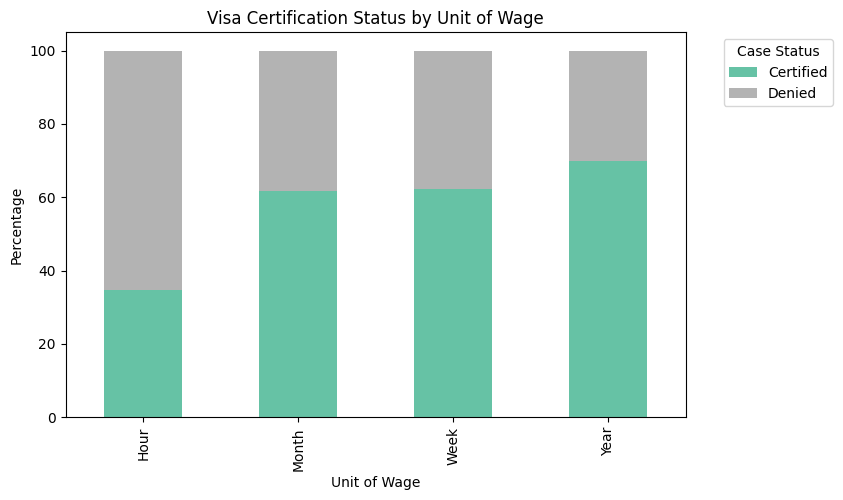

In [175]:
# Visualization of unit of wage vs visa certification status

wage_unit_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Unit of Wage")
plt.ylabel("Percentage")
plt.xlabel("Unit of Wage")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates vary considerably across different wage units.
- Positions offering wages on a **yearly basis** have the highest certification rate, with approximately **69.9%** of applications being certified.
- Weekly and monthly wage structures show similar certification rates of around **62%**.
- Positions with **hourly wages** have the lowest certification rate (**34.6%**) and the highest denial rate (**65.4%**).
- The difference between yearly wage positions (69.9%) and hourly wage positions (34.6%) is more than **35 percentage points**.
- The chart suggests that applications associated with yearly salaries are substantially more likely to be certified than those associated with hourly wages.

### Business Insight

- Positions offering yearly salaries appear to have a much higher likelihood of visa certification compared to hourly-paid positions.
- This may indicate that long-term, salaried employment opportunities are viewed more favorably during the certification process.
- The unit of wage appears to be an important factor and is likely to contribute meaningful predictive power to the final machine learning model.

## Full-Time Position vs Visa Certification Status

In [176]:
# Full-time position vs visa certification status

fulltime_status = pd.crosstab(
    data["full_time_position"],
    data["case_status"],
    normalize="index"
) * 100

fulltime_status.round(2)

case_status,Certified,Denied
full_time_position,,
N,68.53,31.47
Y,66.58,33.42


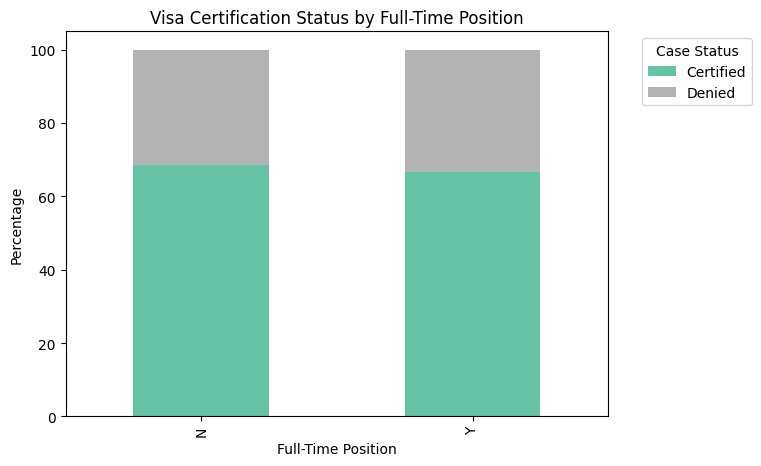

In [177]:
# Visualization of full-time position vs visa certification status

fulltime_status.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    colormap="Set2"
)

plt.title("Visa Certification Status by Full-Time Position")
plt.ylabel("Percentage")
plt.xlabel("Full-Time Position")
plt.legend(title="Case Status", bbox_to_anchor=(1.05,1))
plt.show()

### Observations

- Visa certification rates are very similar for full-time and part-time positions.
- Part-time positions show a certification rate of **68.5%**, while full-time positions show a certification rate of **66.6%**.
- The difference between the two groups is relatively small, at less than **2 percentage points**.
- The stacked bar chart shows nearly identical proportions of certified and denied applications across both categories.
- Based on the available data, full-time status does not appear to have a strong influence on visa certification outcomes.

### Business Insight

- Whether a position is full-time or part-time does not appear to significantly affect the likelihood of visa certification.
- Compared with education level, job experience, and wage structure, full-time status appears to be a relatively weak predictor of visa approval.
- This variable may contribute limited additional information to the final machine learning model.

### Key Findings from Categorical Variables

- Education level shows the strongest relationship with visa certification outcomes, with certification rates increasing substantially for applicants with advanced degrees.
- Unit of wage is also an important factor, with yearly-paid positions having much higher certification rates than hourly-paid positions.
- Applicants with prior job experience have a noticeably higher certification rate than those without experience.
- Region of employment and continent show moderate differences in certification rates.
- Job training requirement and full-time status show very little variation in certification rates and appear to have a weaker relationship with visa outcomes.

## Numerical Variables vs Case Status

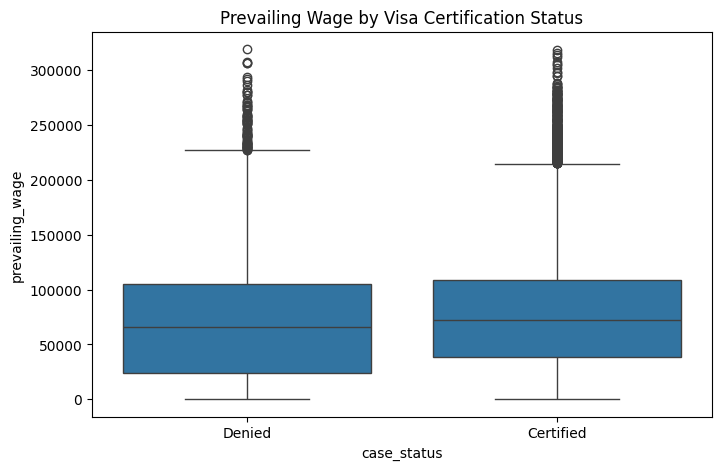

In [178]:
# Comparing prevailing wage across certification outcomes

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="case_status", y="prevailing_wage")

plt.title("Prevailing Wage by Visa Certification Status")
plt.show()

In [179]:
# Summary statistics by case status

data.groupby("case_status")["prevailing_wage"].describe()

,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.0,77293.619243,52042.715576,2.1367,38375.330,72486.27,108879.1075,318446.05
Denied,8462.0,68748.681580,53890.166031,2.9561,23497.295,65431.46,105097.6400,319210.27


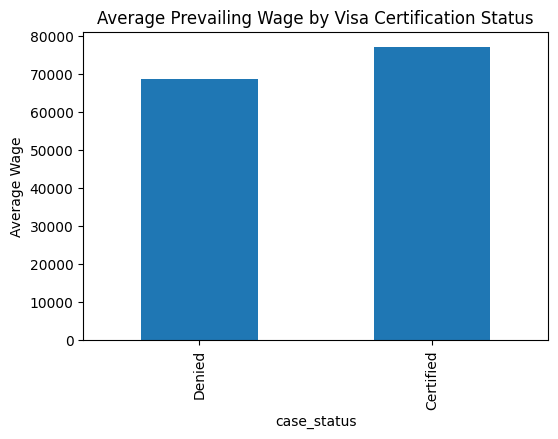

In [180]:
# Average prevailing wage by visa certification status
data.groupby("case_status")["prevailing_wage"].mean().sort_values().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Prevailing Wage by Visa Certification Status")
plt.ylabel("Average Wage")
plt.show()

### Observations

- Certified applications generally have higher prevailing wages than denied applications.
- The median prevailing wage for certified applications is approximately **$72,486**, compared to **$65,431** for denied applications.
- The average prevailing wage is also higher for certified applications (**$77,294**) than for denied applications (**$68,749**).
- The boxplot shows that the distribution of wages for certified applications is shifted slightly upward compared to denied applications.
- Both groups contain several high-wage outliers, indicating that some positions offer substantially higher wages than the typical application.
- Although there is considerable overlap between the two distributions, applicants with higher prevailing wages appear to have a greater likelihood of visa certification.

### Business Insight

- Higher-paying positions appear to have a better chance of receiving visa certification.
- This may be because higher wages indicate specialized skills, greater experience requirements, or occupations that are in higher demand.
- Prevailing wage is likely to be an important predictor in the final machine learning model and should be retained for further analysis.

## Number of Employees vs Visa Certification Status

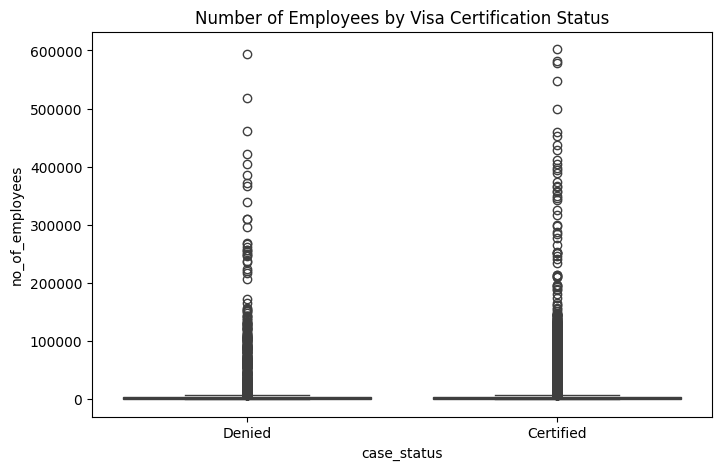

In [181]:
# Comparing company size across certification outcomes

plt.figure(figsize=(8,5))
sns.boxplot(
    data=data,
    x="case_status",
    y="no_of_employees"
)

plt.title("Number of Employees by Visa Certification Status")
plt.show()

In [182]:
# Summary statistics by case status

data.groupby("case_status")["no_of_employees"].describe()

,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.0,5807.055882,23119.565783,11.0,1035.25,2147.0,3575.00,602069.0
Denied,8462.0,5385.601040,22382.740832,11.0,991.00,2032.5,3386.75,594472.0


### Observations

- Certified applications are associated with slightly larger employers compared to denied applications.
- The median number of employees for certified applications is approximately **2,147**, compared to **2,033** for denied applications.
- The average company size is also slightly higher for certified applications (**5,807 employees**) than for denied applications (**5,386 employees**).
- Both groups contain a large number of extreme values, indicating the presence of very large organizations in the dataset.
- The boxplots for certified and denied applications show considerable overlap, suggesting that company size alone is not a strong differentiating factor.
- While larger companies appear to have a marginally higher certification rate, the difference is much smaller than the differences observed for education level, job experience, and wage structure.

### Business Insight

- Larger employers may have a slightly greater likelihood of obtaining visa certification, possibly due to greater resources, established hiring processes, or a stronger history of sponsoring foreign workers.
- However, company size does not appear to be one of the primary drivers of visa certification outcomes.
- The variable may still contribute useful information when combined with other applicant and employer characteristics in the machine learning models.

## Year of Establishment vs Visa Certification Status

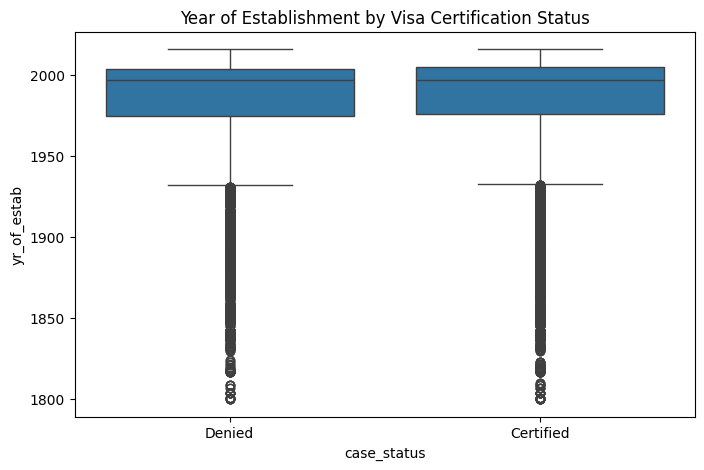

In [183]:
# Comparing company establishment year across certification outcomes

plt.figure(figsize=(8,5))
sns.boxplot(
    data=data,
    x="case_status",
    y="yr_of_estab"
)

plt.title("Year of Establishment by Visa Certification Status")
plt.show()

In [184]:
# Summary statistics by case status

data.groupby("case_status")["yr_of_estab"].describe()

,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.0,1979.666765,42.278601,1800.0,1976.0,1997.0,2005.0,2016.0
Denied,8462.0,1978.893406,42.541819,1800.0,1975.0,1997.0,2004.0,2016.0


### Observations

- The distributions of company establishment year are very similar for certified and denied applications.
- The median establishment year is **1997** for both groups, indicating that the typical employer age is nearly identical regardless of certification outcome.
- The average establishment year is also very similar, with certified applications associated with companies established around **1980**, compared to **1979** for denied applications.
- The boxplots show substantial overlap between the two groups, suggesting that company age does not strongly differentiate certified and denied applications.
- Both certified and denied applications include employers ranging from long-established organizations to relatively newer companies.
- Based on the available data, there is little evidence that older or newer companies consistently achieve higher visa certification rates.

### Business Insight

- The age of the employer does not appear to have a meaningful impact on visa certification outcomes.
- Unlike education level, job experience, wage structure, and prevailing wage, company establishment year appears to be a relatively weak predictor of visa approval.
- While the variable may still contribute some information when combined with other features, it is unlikely to be a primary driver of certification decisions.

## Key Findings from Bivariate Analysis

- Education level shows the strongest relationship with visa certification outcomes. Applicants with Master's and Doctorate degrees have substantially higher certification rates than applicants with only a High School education.
- Job experience is another important factor, with experienced applicants showing considerably higher certification rates than applicants without prior work experience.
- Wage-related variables appear to play an important role. Applications associated with yearly wage structures and higher prevailing wages tend to have higher certification rates.
- Region of employment and continent show moderate differences in certification rates, suggesting that geographic factors may influence certification outcomes.
- Company size appears to have a weak positive relationship with certification, although the difference between certified and denied applications is relatively small.
- Job training requirement, full-time status, and company establishment year show little variation in certification rates and appear to be weaker predictors of visa outcomes.
- Overall, applicant qualifications and compensation-related variables appear to be more influential than employer characteristics in determining visa certification outcomes.

## Multivariate Analysis

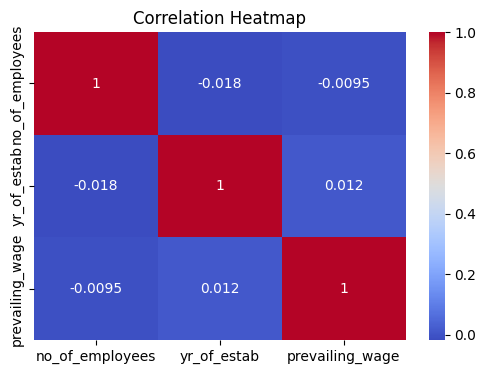

In [185]:
# Correlation among numerical variables

plt.figure(figsize=(6,4))

sns.heatmap(
    data[['no_of_employees','yr_of_estab','prevailing_wage']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [186]:
# Certification rate by education and experience

edu_exp = pd.crosstab(
    [data['education_of_employee'],
     data['has_job_experience']],
    data['case_status'],
    normalize='index'
) * 100

edu_exp.round(2)

case_status                               Certified  Denied
education_of_employee has_job_experience                   
Bachelor's            N                       51.31   48.69
                      Y                       70.27   29.73
Doctorate             N                       80.13   19.87
                      Y                       92.57    7.43
High School           N                       31.66   68.34
                      Y                       35.67   64.33
Master's              N                       64.29   35.71
                      Y                       88.78   11.22

## Observations - Multivariate Analysis

### Correlation Heatmap

- The numerical variables show very weak correlations with each other.
- The correlation between `no_of_employees` and `yr_of_estab` is approximately **-0.02**.
- The correlation between `no_of_employees` and `prevailing_wage` is approximately **-0.01**.
- The correlation between `yr_of_estab` and `prevailing_wage` is approximately **0.01**.
- Since all correlation values are close to zero, there is no evidence of strong linear relationships among the numerical variables.
- The absence of strong correlations suggests that multicollinearity is unlikely to be a concern for the machine learning models.

### Education Level and Job Experience

- Visa certification rates increase substantially when higher education is combined with prior job experience.
- Applicants with a **Doctorate and prior job experience** have the highest certification rate (**92.57%**).
- Applicants with a **Master's degree and prior job experience** also have a very high certification rate (**88.78%**).
- Applicants with a **Bachelor's degree and prior job experience** have a certification rate of **70.27%**, compared to **51.31%** for Bachelor's degree holders without experience.
- Applicants with only a **High School education** have the lowest certification rates regardless of experience.
- The impact of job experience appears stronger among applicants with higher educational qualifications.

### Key Insights

- Education level and job experience appear to work together in influencing visa certification outcomes.
- Applicants with both advanced qualifications and relevant work experience have the highest likelihood of certification.
- The findings reinforce earlier observations that education and work experience are among the most important factors associated with visa approval decisions.
- Numerical variables show limited relationships with one another, while categorical variables such as education and experience demonstrate stronger associations with the target variable.

## Finaly EDA Summary
## Key Findings from Exploratory Data Analysis

- Approximately 66.8% of visa applications in the dataset were certified, while 33.2% were denied.
- Education level emerged as one of the strongest factors associated with visa certification outcomes. Applicants with Master's and Doctorate degrees showed significantly higher certification rates than applicants with only a High School education.
- Prior job experience was positively associated with visa certification, with experienced applicants receiving certifications more frequently than those without experience.
- Wage-related variables also appeared important. Applications with yearly wage structures and higher prevailing wages generally showed higher certification rates.
- Region of employment and continent demonstrated moderate differences in certification rates.
- Job training requirement, full-time position status, and company establishment year showed relatively weak relationships with certification outcomes.
- Company size exhibited a slight positive relationship with certification, although the difference was less pronounced than other factors.
- The combination of higher education and prior job experience resulted in the highest certification rates, highlighting the importance of applicant qualifications.
- Correlation analysis indicated no strong relationships among the numerical variables, suggesting that multicollinearity is unlikely to be an issue.

# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

## Missing Value Treatment

In [187]:
# Checking missing values

data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


### Missing Value Treatment

- Missing values were checked across all variables in the dataset.
- No missing values were found in any of the features or the target variable.
- Since the dataset is complete, no missing value imputation or treatment was required.
- The absence of missing values simplifies the data preparation process and ensures that all available observations can be used for model building.

### Business Insight

- The dataset is of good quality from a completeness perspective, as no information is missing for any visa application.

## Outlier Detection and Treatment

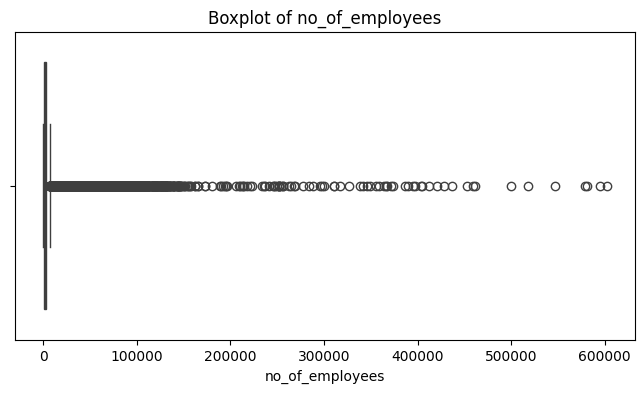

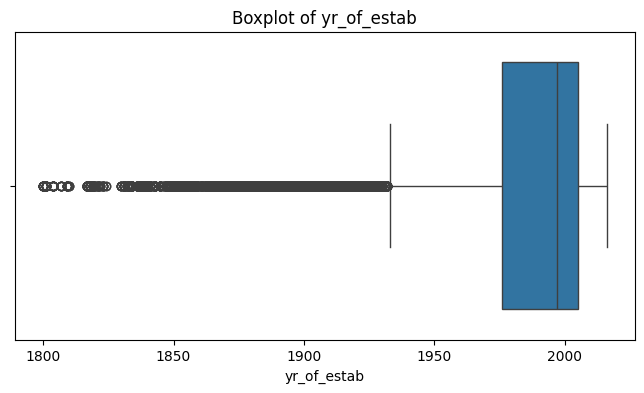

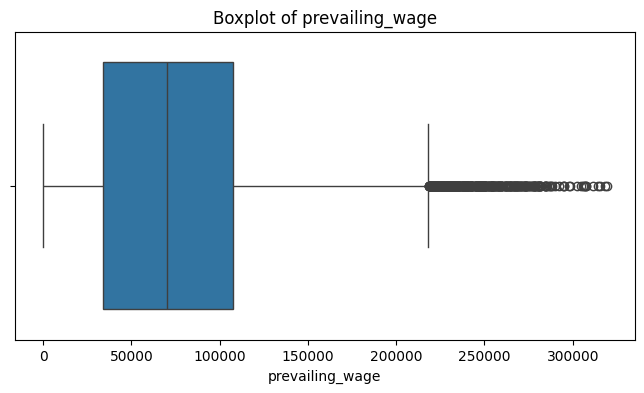

In [188]:
# Boxplots for numerical variables

numerical_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=data[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

### Outlier Detection and Treatment

- Boxplots were used to identify potential outliers in the numerical variables.
- The variables **no_of_employees** and **prevailing_wage** contain a considerable number of extreme values.
- The variable **yr_of_estab** also shows some observations outside the whiskers, primarily representing very old companies.
- The identified outliers appear to be legitimate business observations rather than data entry errors. For example, large multinational organizations can employ hundreds of thousands of employees, and certain specialized positions may offer exceptionally high wages.
- Since the objective of this project is prediction and the models used are primarily tree-based algorithms (Decision Tree, Random Forest, Bagging, AdaBoost, Gradient Boosting, and XGBoost), which are generally robust to outliers, no outlier treatment was performed.
- Therefore, all observations were retained for subsequent analysis and model building.

### Business Insight

- The presence of large employers and high-paying positions reflects the diversity of organizations and job opportunities represented in the visa application process.
- Retaining these observations helps preserve potentially valuable information that may contribute to identifying successful visa applications.

## Feature Engineering / Data Quality Treatment

In [189]:
# Check negative values in no_of_employees

neg_count = (data["no_of_employees"] < 0).sum()

print("Negative no_of_employees rows:", neg_count)

Negative no_of_employees rows: 0


### Feature Engineering / Data Quality Treatment

- During the initial data quality assessment, 33 records were identified with negative values in the `no_of_employees` variable.
- Since the number of employees cannot be negative, these values were considered invalid.
- The values were corrected by converting them to their absolute values.
- A subsequent validation confirmed that no negative employee counts remained in the dataset.
- This correction improved data quality while preserving all available observations.

### Business Insight

- Correcting invalid employee counts ensures that company size is accurately represented and prevents misleading information from influencing model performance.

## Remove Identifier Column

In [190]:
# Remove unique identifier

data = data.drop("case_id", axis=1)

print("Dataset shape after dropping case_id:", data.shape)

Dataset shape after dropping case_id: (25480, 11)


### Remove Identifier Column

- The variable `case_id` was removed from the dataset before model building.
- `case_id` is a unique identifier assigned to each visa application and does not contain any predictive information.
- Retaining this variable could introduce unnecessary noise into the model without contributing to prediction accuracy.
- After removing `case_id`, the dataset contains **25,480 observations and 11 variables**.

### Business Insight

- Removing non-informative identifier fields helps ensure that the machine learning models focus on meaningful applicant and employer characteristics rather than arbitrary record identifiers.

## Encode Target Variable

In [191]:
# Encode target variable

data["case_status"] = data["case_status"].apply(
    lambda x: 1 if x == "Certified" else 0
)

# Verify encoding
data["case_status"].value_counts()

,count
case_status,
1,17018
0,8462


### Target Variable Encoding

- The target variable `case_status` was converted from categorical values to numerical values to make it suitable for machine learning algorithms.
- Certified applications were encoded as **1**, while Denied applications were encoded as **0**.
- After encoding, the dataset contains **17,018 certified applications** and **8,462 denied applications**.
- The class distribution remains unchanged after the transformation.
- This encoding enables the classification models to learn patterns associated with visa certification outcomes.

### Business Insight

- Converting the target variable into a numerical format allows machine learning algorithms to distinguish between approved and denied visa applications while preserving the original business meaning of the outcome.

## Create Features and Target Variables

In [192]:
# Define features and target

X = data.drop("case_status", axis=1)
y = data["case_status"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (25480, 10)
Target variable shape: (25480,)


### Create Features and Target Variables

- The dataset was separated into predictor variables (`X`) and the target variable (`y`).
- The feature matrix contains **25,480 observations and 10 predictor variables**.
- The target variable contains **25,480 observations**, corresponding to the visa certification outcome.
- Separating the predictors and target variable prepares the dataset for model training and evaluation.

### Business Insight

- Separating the target variable from the predictor variables allows machine learning models to learn the factors associated with visa certification outcomes while ensuring that the outcome itself is not used as an input feature.

## Train-Test Split

In [193]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(round(y_train.value_counts(normalize=True) * 100, 2))

print("\nTesting target distribution:")
print(round(y_test.value_counts(normalize=True) * 100, 2))

Training set shape: (17836, 10)
Testing set shape: (7644, 10)

Training target distribution:
case_status
1    66.79
0    33.21
Name: proportion, dtype: float64

Testing target distribution:
case_status
1    66.78
0    33.22
Name: proportion, dtype: float64


### Train-Test Split

- The dataset was divided into training and testing datasets using a 70:30 split.
- The training dataset contains **17,836 observations**, while the testing dataset contains **7,644 observations**.
- Stratified sampling was used to ensure that the class distribution remained consistent across both datasets.
- The proportion of certified applications in the training set is **66.79%**, compared to **66.78%** in the testing set.
- Similarly, denied applications represent **33.21%** of the training set and **33.22%** of the testing set.
- The nearly identical class distributions confirm that the train-test split successfully preserved the original characteristics of the target variable.

### Business Insight

- Maintaining a consistent class distribution between training and testing datasets helps ensure that model performance is evaluated fairly and reflects real-world visa application patterns.

## One-Hot Encoding of Categorical Variables

In [194]:
# One-hot encoding

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align train and test datasets

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Training set shape after encoding:", X_train.shape)
print("Testing set shape after encoding:", X_test.shape)

print("\nNumber of features after encoding:", X_train.shape[1])

Training set shape after encoding: (17836, 21)
Testing set shape after encoding: (7644, 21)

Number of features after encoding: 21


### Encoding Categorical Variables

- Machine learning algorithms require numerical inputs; therefore, categorical variables were converted into numerical format using one-hot encoding.
- The parameter `drop_first=True` was used to avoid creating redundant variables and reduce the risk of multicollinearity.
- After encoding, the number of predictor variables increased from **10** to **21**.
- The training dataset contains **17,836 observations and 21 features**, while the testing dataset contains **7,644 observations and 21 features**.
- The training and testing datasets were aligned to ensure both contained the same set of predictor variables.

### Business Insight

- Converting categorical variables into numerical form enables machine learning algorithms to utilize information such as education level, continent, region of employment, wage unit, and work experience when predicting visa certification outcomes.

## Class Imbalance Check

In [195]:
# Class distribution in training data

print("Class Distribution:")
print(y_train.value_counts())

print("\nClass Percentage:")
print(round(y_train.value_counts(normalize=True) * 100, 2))

Class Distribution:
case_status
1    11913
0     5923
Name: count, dtype: int64

Class Percentage:
case_status
1    66.79
0    33.21
Name: proportion, dtype: float64


### Class Imbalance Check

- The target variable exhibits a moderate class imbalance.
- Certified applications account for **11,913 observations (66.79%)**, while denied applications account for **5,923 observations (33.21%)** in the training dataset.
- The majority class (Certified) contains approximately twice as many observations as the minority class (Denied).
- Although the imbalance is not extreme, it may influence model performance by biasing predictions toward the majority class.
- To assess the impact of class imbalance, models will be developed and evaluated using:
  - Original training data
  - SMOTE oversampled training data
  - Random undersampled training data

  ### Business Insight

- Since certified applications occur more frequently than denied applications, a model trained only on the original data may become biased toward predicting certification.
- Evaluating models on oversampled and undersampled datasets will help determine whether balancing the classes improves the identification of denied applications.

## Summary of Data Pre-processing

- No missing values were found in the dataset; therefore, no imputation was required.
- Outliers were identified in `no_of_employees` and `prevailing_wage`, but were retained because they represent valid business observations and tree-based algorithms are generally robust to outliers.
- Invalid negative employee counts identified during data quality checks were corrected.
- The unique identifier `case_id` was removed because it does not contribute predictive information.
- The target variable `case_status` was encoded into numerical format.
- The dataset was divided into training and testing datasets using a stratified 70:30 split.
- Categorical variables were transformed using one-hot encoding, increasing the number of features from 10 to 21.
- A moderate class imbalance was identified, motivating the use of SMOTE oversampling and random undersampling during model development.

# **Model Building - Original Data**

## Model Evaluation Function

In [196]:
# Function to evaluate model performance

def model_performance_classification(model, predictors, target):

    pred = model.predict(predictors)

    performance = pd.DataFrame(
        {
            "Accuracy": [accuracy_score(target, pred)],
            "Precision": [precision_score(target, pred)],
            "Recall": [recall_score(target, pred)],
            "F1 Score": [f1_score(target, pred)],
        }
    )

    return performance

## Build Decision Tree Classifier (Original Data)

In [197]:
# Train the Model
# Decision Tree Classifier

dtree = DecisionTreeClassifier(
    random_state=1
)

dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [198]:
# Check Training Performance
# Training performance

dtree_train_perf = model_performance_classification(
    dtree,
    X_train,
    y_train
)

print("Training Performance")
dtree_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,1.0,1.0,1.0,1.0


In [199]:
# Check Testing Performance
# Testing performance

dtree_test_perf = model_performance_classification(
    dtree,
    X_test,
    y_test
)

print("Testing Performance")
dtree_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.664835,0.752232,0.742801,0.747487


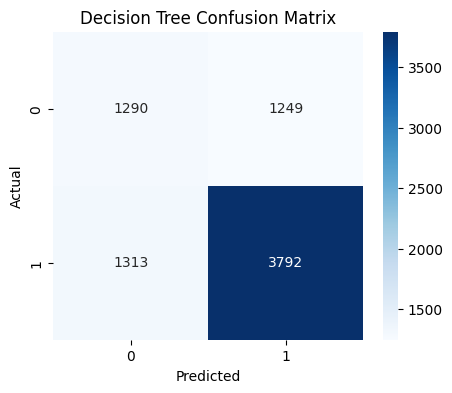

In [200]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    dtree.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [201]:
# Classification Report

print(classification_report(
    y_test,
    dtree.predict(X_test)
))

              precision    recall  f1-score   support

           0       0.50      0.51      0.50      2539
           1       0.75      0.74      0.75      5105

    accuracy                           0.66      7644
   macro avg       0.62      0.63      0.62      7644
weighted avg       0.67      0.66      0.67      7644



### Decision Tree Classifier - Observations

- The Decision Tree achieved perfect performance on the training dataset, with an accuracy, precision, recall, and F1-score of 100%.
- On the testing dataset, the model achieved an accuracy of **66.5%**, a precision of **75.2%**, a recall of **74.3%**, and an F1-score of **74.7%**.
- The large gap between training and testing performance indicates that the model has severely overfitted the training data.
- The model learned the training observations extremely well but struggled to generalize to unseen data.
- The confusion matrix shows that the model correctly identified **3,792 certified applications** and **1,290 denied applications**.
- However, the model also misclassified a considerable number of applications, particularly denied cases.
- Although the model demonstrates reasonable recall and precision on the testing dataset, its strong overfitting limits its reliability for practical deployment.

### Business Insight

- While the Decision Tree captures patterns present in the training data, it does not generalize effectively to new visa applications.
- The model serves as a useful baseline but is unlikely to be the best choice for final implementation.
- Ensemble methods such as Bagging, Random Forest, and Boosting are expected to improve generalization performance and reduce overfitting.

## Bagging Classifier (Original Data)

In [202]:
# Train Model
# Bagging Classifier

bagging_model = BaggingClassifier(
    random_state=1
)

bagging_model.fit(X_train, y_train)

BaggingClassifier(random_state=1)

In [203]:
# Training performance

bagging_train_perf = model_performance_classification(
    bagging_model,
    X_train,
    y_train
)

print("Training Performance")
bagging_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.985198,0.99181,0.985982,0.988887


In [204]:
# Testing performance

bagging_test_perf = model_performance_classification(
    bagging_model,
    X_test,
    y_test
)

print("Testing Performance")
bagging_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.691523,0.771711,0.764153,0.767913


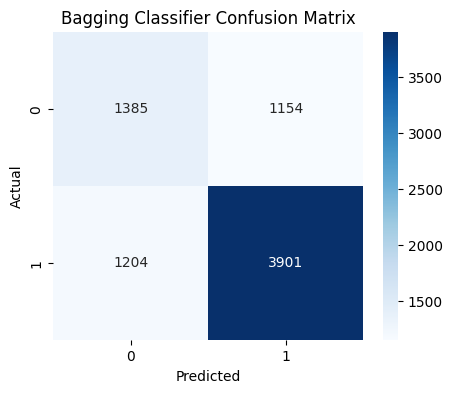

In [205]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    bagging_model.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bagging Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [206]:
# Classification Report
print(
    classification_report(
        y_test,
        bagging_model.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.53      0.55      0.54      2539
           1       0.77      0.76      0.77      5105

    accuracy                           0.69      7644
   macro avg       0.65      0.65      0.65      7644
weighted avg       0.69      0.69      0.69      7644



### Bagging Classifier - Observations

- The Bagging Classifier achieved an accuracy of **98.5%** on the training dataset and **69.2%** on the testing dataset.
- Compared to the Decision Tree model, the Bagging Classifier improved accuracy, precision, recall, and F1-score on the testing dataset.
- The model achieved a testing precision of **77.2%**, recall of **76.4%**, and F1-score of **76.8%**.
- Although the training performance remains substantially higher than the testing performance, the degree of overfitting is lower than that observed in the Decision Tree model.
- The confusion matrix shows that the model correctly classified **1,385 denied applications** and **3,901 certified applications**.
- The ensemble approach helps reduce the variance associated with a single decision tree and improves generalization performance.

### Business Insight

- Combining multiple decision trees through bagging improves prediction stability and overall model performance.
- The model demonstrates a better balance between identifying certified and denied applications compared to the standalone Decision Tree.
- Bagging appears to be a stronger candidate for final model selection than the basic Decision Tree model.

## Random Forest (Original Data)

In [207]:
# Train Model
# Random Forest Classifier

rf_model = RandomForestClassifier(
    random_state=1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [208]:
# Training performance

rf_train_perf = model_performance_classification(
    rf_model,
    X_train,
    y_train
)

print("Training Performance")
rf_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.999944,1.0,0.999916,0.999958


In [209]:
# Testing performance

rf_test_perf = model_performance_classification(
    rf_model,
    X_test,
    y_test
)

print("Testing Performance")
rf_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.720827,0.768869,0.832125,0.799247


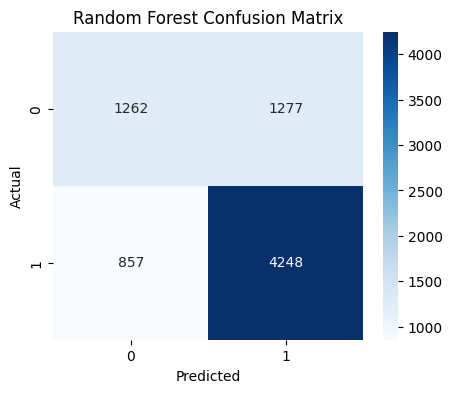

In [210]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    rf_model.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [211]:
# Classification Report
print(
    classification_report(
        y_test,
        rf_model.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.60      0.50      0.54      2539
           1       0.77      0.83      0.80      5105

    accuracy                           0.72      7644
   macro avg       0.68      0.66      0.67      7644
weighted avg       0.71      0.72      0.71      7644



### Random Forest Classifier - Observations

- The Random Forest model achieved an accuracy of **72.1%** on the testing dataset, which is the highest among the models evaluated so far.
- The model achieved a precision of **76.9%**, recall of **83.2%**, and F1-score of **79.9%** on the testing dataset.
- Compared to the Decision Tree and Bagging models, Random Forest demonstrates superior overall performance and better generalization capability.
- The model correctly identified **4,248 certified applications** and **1,262 denied applications**.
- Recall for certified applications is particularly high, indicating that the model successfully identifies the majority of applications that are likely to be certified.
- Although some overfitting is still present, the Random Forest model generalizes better than the standalone Decision Tree.

### Business Insight

- Random Forest provides a strong balance between accuracy, precision, and recall, making it a promising candidate for visa certification prediction.
- The model is effective at identifying applications likely to be certified while maintaining reasonable performance for denied applications.
- Based on the results obtained so far, Random Forest is one of the strongest candidates for further tuning and final model selection.

## AdaBoost (Original Data)

In [212]:
#Train Model
# AdaBoost Classifier

adaboost_model = AdaBoostClassifier(
    random_state=1
)

adaboost_model.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

In [213]:
# AdaBoost Classifier

adaboost_model = AdaBoostClassifier(
    random_state=1
)

adaboost_model.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

In [214]:
# Training performance

adaboost_train_perf = model_performance_classification(
    adaboost_model,
    X_train,
    y_train
)

print("Training Performance")
adaboost_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.739684,0.762039,0.88735,0.819934


In [215]:
# Testing performance

adaboost_test_perf = model_performance_classification(
    adaboost_model,
    X_test,
    y_test
)

print("Testing Performance")
adaboost_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.735348,0.758905,0.884819,0.817039


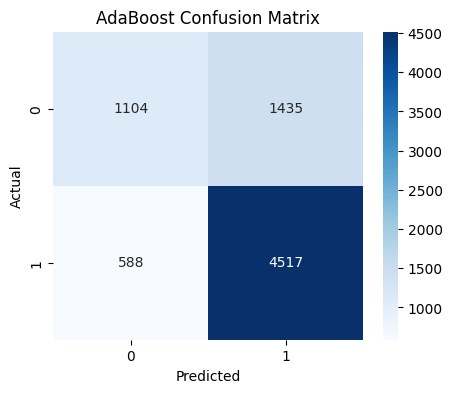

In [216]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    adaboost_model.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [217]:
# Classification Report
print(
    classification_report(
        y_test,
        adaboost_model.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.65      0.43      0.52      2539
           1       0.76      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.66      0.67      7644
weighted avg       0.72      0.74      0.72      7644



### AdaBoost Classifier - Observations

- The AdaBoost model achieved a training accuracy of **73.97%** and a testing accuracy of **73.53%**.
- The model achieved a testing precision of **75.89%**, recall of **88.48%**, and F1-score of **81.70%**.
- The training and testing metrics are very similar, indicating that the model generalizes well to unseen data and exhibits minimal overfitting.
- AdaBoost achieved the highest recall among all models evaluated so far, successfully identifying **88.48%** of certified applications.
- The confusion matrix shows that the model correctly classified **4,517 certified applications** and **1,104 denied applications**.
- Compared with the Decision Tree, Bagging, and Random Forest models, AdaBoost delivered the best overall performance based on testing accuracy and F1-score.
- The model demonstrates a strong balance between predictive accuracy and generalization capability.

### Business Insight

- AdaBoost is highly effective at identifying applications that are likely to be certified.
- The model minimizes the number of certified applications that are incorrectly classified as denied, making it particularly useful for supporting visa certification decisions.
- The minimal difference between training and testing performance suggests that the model is reliable and likely to perform consistently on new applications.
- Based on the results obtained so far, AdaBoost is one of the strongest candidates for hyperparameter tuning and final model selection.

## Gradient Boosting (Original Data)

In [218]:
# Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    random_state=1
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [219]:
# Training Performance
gb_train_perf = model_performance_classification(
    gb_model,
    X_train,
    y_train
)

print("Training Performance")
gb_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.758802,0.783042,0.88374,0.830349


In [220]:
# Testing Performance
gb_test_perf = model_performance_classification(
    gb_model,
    X_test,
    y_test
)

print("Testing Performance")
gb_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.744767,0.772366,0.876004,0.820927


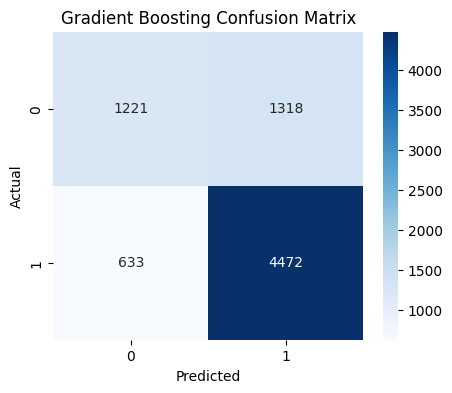

In [221]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    gb_model.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [222]:
# Classification Report
print(
    classification_report(
        y_test,
        gb_model.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.66      0.48      0.56      2539
           1       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.72      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



### Gradient Boosting Classifier - Observations

- The Gradient Boosting model achieved a training accuracy of **75.88%** and a testing accuracy of **74.48%**.
- The model achieved a testing precision of **77.24%**, recall of **87.60%**, and F1-score of **82.09%**.
- The training and testing metrics are very close, indicating excellent generalization and minimal overfitting.
- The model correctly classified **4,472 certified applications** and **1,221 denied applications** on the testing dataset.
- Compared to all previously evaluated models, Gradient Boosting achieved the highest testing accuracy and F1-score.
- The model demonstrates a strong balance between precision and recall while maintaining stable performance on unseen data.
- The high recall indicates that the model is effective at identifying applications that are likely to be certified.

### Business Insight

- Gradient Boosting appears to be highly effective for predicting visa certification outcomes.
- The model provides a strong balance between predictive accuracy and generalization capability.
- The low level of overfitting suggests that the model is likely to perform consistently on future visa applications.
- Based on the results obtained so far, Gradient Boosting is one of the strongest candidates for hyperparameter tuning and final deployment.

### Conclusion for Original Data Models

### Summary of Models Built on Original Data

- Five classification models were developed using the original training dataset:
  - Decision Tree
  - Bagging Classifier
  - Random Forest
  - AdaBoost
  - Gradient Boosting

- Ensemble methods consistently outperformed the standalone Decision Tree model.

- Gradient Boosting achieved the highest testing accuracy (**74.48%**) and F1-score (**82.09%**), making it the best-performing model on the original dataset.

- AdaBoost also delivered strong performance with excellent recall and minimal overfitting.

- Random Forest demonstrated good predictive capability but showed slightly lower performance than the boosting-based models.

- Decision Tree exhibited severe overfitting and was the weakest performer among the evaluated models.

# **Model Building - Oversampled Data**

In [223]:
# Apply SMOTE

smote = SMOTE(random_state=1)

X_train_over, y_train_over = smote.fit_resample(
    X_train,
    y_train
)

print("Original class distribution:")
print(y_train.value_counts())

print("\nOversampled class distribution:")
print(y_train_over.value_counts())

Original class distribution:
case_status
1    11913
0     5923
Name: count, dtype: int64

Oversampled class distribution:
case_status
1    11913
0    11913
Name: count, dtype: int64


### SMOTE Oversampling

- The original training dataset exhibited a moderate class imbalance, with certified applications representing approximately 67% of the observations.
- SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the target classes in the training dataset.
- After applying SMOTE, both classes contain **11,913 observations**, resulting in a perfectly balanced training dataset.
- SMOTE generates synthetic examples of the minority class rather than simply duplicating existing observations.
- Balancing the dataset may help improve the model's ability to identify denied applications and reduce bias toward the majority class.
- The testing dataset was not modified to ensure unbiased model evaluation.

### Business Insight

- A balanced dataset allows the models to learn patterns associated with denied applications more effectively.
- This may improve the identification of potentially risky or non-compliant visa applications.
- Comparing model performance before and after SMOTE will help determine whether class balancing improves predictive performance.

## Decision Tree - Oversampled Data

In [224]:
# Train Model
# Decision Tree - Oversampled Data

dtree_over = DecisionTreeClassifier(
    random_state=1
)

dtree_over.fit(
    X_train_over,
    y_train_over
)

DecisionTreeClassifier(random_state=1)

In [225]:
# Training Performance
dtree_over_train_perf = model_performance_classification(
    dtree_over,
    X_train_over,
    y_train_over
)

print("Training Performance")
dtree_over_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,1.0,1.0,1.0,1.0


In [226]:
# Testing Performance
dtree_over_test_perf = model_performance_classification(
    dtree_over,
    X_test,
    y_test
)

print("Testing Performance")
dtree_over_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.657248,0.75383,0.722821,0.738


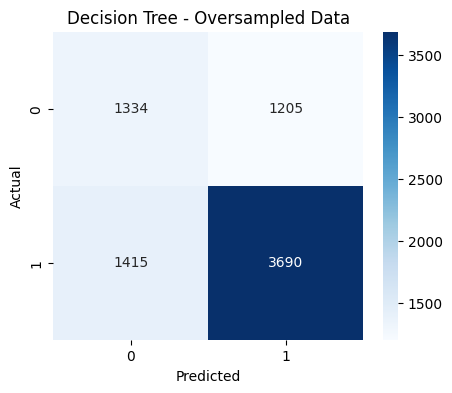

In [227]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    dtree_over.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree - Oversampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [228]:
# Classification Report
print(
    classification_report(
        y_test,
        dtree_over.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.49      0.53      0.50      2539
           1       0.75      0.72      0.74      5105

    accuracy                           0.66      7644
   macro avg       0.62      0.62      0.62      7644
weighted avg       0.66      0.66      0.66      7644



### Decision Tree - Oversampled Data - Observations

- The Decision Tree achieved perfect performance on the oversampled training dataset, with all evaluation metrics equal to 100%.
- On the testing dataset, the model achieved an accuracy of **65.72%**, precision of **75.38%**, recall of **72.28%**, and F1-score of **73.80%**.
- The large gap between training and testing performance indicates severe overfitting.
- Compared to the Decision Tree built on the original dataset, oversampling did not improve model performance.
- Although the model identified slightly more denied applications correctly, overall predictive performance decreased marginally.
- The model continues to memorize training observations rather than generalizing effectively to unseen data.

### Business Insight

- Applying SMOTE alone does not improve the performance of a standalone Decision Tree model.
- The model remains highly sensitive to training data and is therefore not a strong candidate for final deployment.
- More sophisticated ensemble methods are expected to benefit more from oversampling.

## Bagging Classifier (Oversampled Data)

In [229]:
# Train Model
# Bagging Classifier - Oversampled Data

bagging_over = BaggingClassifier(
    random_state=1
)

bagging_over.fit(
    X_train_over,
    y_train_over
)

BaggingClassifier(random_state=1)

In [230]:
# Training Performance
bagging_over_train_perf = model_performance_classification(
    bagging_over,
    X_train_over,
    y_train_over
)

print("Training Performance")
bagging_over_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.987451,0.991952,0.982876,0.987393


In [231]:
# Testing Performance
bagging_over_test_perf = model_performance_classification(
    bagging_over,
    X_test,
    y_test
)

print("Testing Performance")
bagging_over_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.687206,0.773589,0.751616,0.762444


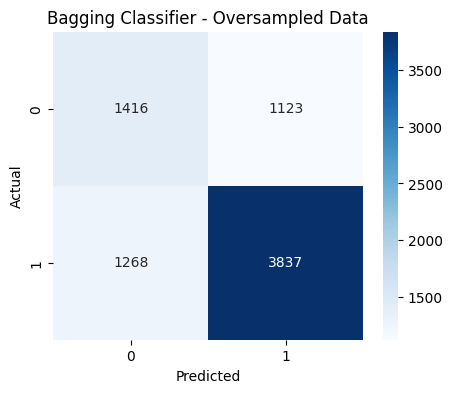

In [232]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    bagging_over.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bagging Classifier - Oversampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [233]:
# Classification Report
print(
    classification_report(
        y_test,
        bagging_over.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.53      0.56      0.54      2539
           1       0.77      0.75      0.76      5105

    accuracy                           0.69      7644
   macro avg       0.65      0.65      0.65      7644
weighted avg       0.69      0.69      0.69      7644



### Bagging Classifier - Oversampled Data - Observations

- The Bagging Classifier achieved a training accuracy of **98.75%** and a testing accuracy of **68.72%**.
- The model achieved a testing precision of **77.36%**, recall of **75.16%**, and F1-score of **76.24%**.
- A noticeable gap between training and testing performance indicates that the model still exhibits overfitting.
- Compared with the Bagging model built on the original dataset, oversampling did not improve overall model performance.
- The model correctly identified **1,416 denied applications**, which is slightly higher than the original Bagging model.
- However, this improvement in identifying denied applications came at the expense of a reduction in overall accuracy and F1-score.
- The model demonstrates better sensitivity toward the minority class but does not achieve better overall predictive performance.

### Business Insight

- SMOTE helped the model learn more patterns associated with denied applications.
- However, the additional synthetic observations did not improve the model's ability to generalize to unseen data.
- The original Bagging model remains a stronger candidate than the oversampled version.

## Random Forest - Oversampled Data

In [234]:
# Train Model
# Random Forest - Oversampled Data

rf_over = RandomForestClassifier(
    random_state=1
)

rf_over.fit(
    X_train_over,
    y_train_over
)

RandomForestClassifier(random_state=1)

In [235]:
# Training Performance
rf_over_train_perf = model_performance_classification(
    rf_over,
    X_train_over,
    y_train_over
)

print("Training Performance")
rf_over_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.999958,1.0,0.999916,0.999958


In [236]:
# Testing Performance
rf_over_test_perf = model_performance_classification(
    rf_over,
    X_test,
    y_test
)

print("Testing Performance")
rf_over_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.719649,0.773449,0.820568,0.796312


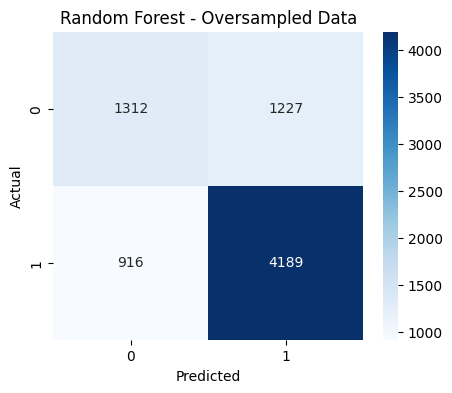

In [237]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_over.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Oversampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [238]:
# Classification Report
print(
    classification_report(
        y_test,
        rf_over.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.59      0.52      0.55      2539
           1       0.77      0.82      0.80      5105

    accuracy                           0.72      7644
   macro avg       0.68      0.67      0.67      7644
weighted avg       0.71      0.72      0.71      7644



### Random Forest - Oversampled Data - Observations

- The Random Forest model achieved a training accuracy of **99.996%** and a testing accuracy of **71.96%**.
- The model achieved a testing precision of **77.34%**, recall of **82.06%**, and F1-score of **79.63%**.
- A significant gap between training and testing performance indicates that the model continues to exhibit overfitting despite the application of SMOTE.
- Compared with the Random Forest model built on the original dataset, oversampling did not produce any meaningful improvement in performance.
- The model correctly classified **4,189 certified applications** and **1,312 denied applications**.
- Although the model remains one of the stronger performers, the original Random Forest model achieved slightly better accuracy, recall, and F1-score.

### Business Insight

- Random Forest already handled the moderate class imbalance reasonably well in the original dataset.
- Applying SMOTE did not substantially improve the model's ability to generalize to unseen data.
- The original Random Forest model remains preferable to the oversampled version based on overall predictive performance.

## AdaBoost - Oversampled Data

In [239]:
# AdaBoost - Oversampled Data

adaboost_over = AdaBoostClassifier(
    random_state=1
)

adaboost_over.fit(
    X_train_over,
    y_train_over
)

AdaBoostClassifier(random_state=1)

In [240]:
# Training Performance
adaboost_over_train_perf = model_performance_classification(
    adaboost_over,
    X_train_over,
    y_train_over
)

print("Training Performance")
adaboost_over_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.782045,0.73467,0.882985,0.802028


In [241]:
# Testing Performance
adaboost_over_test_perf = model_performance_classification(
    adaboost_over,
    X_test,
    y_test
)

print("Testing Performance")
adaboost_over_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.731162,0.759266,0.874829,0.812961


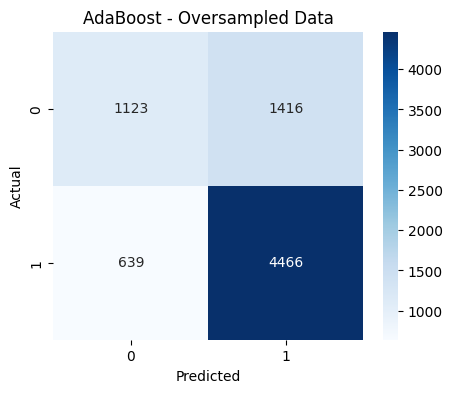

In [242]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    adaboost_over.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost - Oversampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [243]:
# Classification Report
print(
    classification_report(
        y_test,
        adaboost_over.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.64      0.44      0.52      2539
           1       0.76      0.87      0.81      5105

    accuracy                           0.73      7644
   macro avg       0.70      0.66      0.67      7644
weighted avg       0.72      0.73      0.72      7644



### AdaBoost - Oversampled Data - Observations

- The AdaBoost model achieved a training accuracy of **78.20%** and a testing accuracy of **73.12%**.
- The model achieved a testing precision of **75.93%**, recall of **87.48%**, and F1-score of **81.30%**.
- The relatively small difference between training and testing performance indicates good generalization and limited overfitting.
- The model correctly classified **4,466 certified applications** and **1,123 denied applications**.
- Compared with the AdaBoost model trained on the original dataset, oversampling did not provide a meaningful improvement in performance.
- Accuracy, recall, and F1-score decreased slightly after applying SMOTE.
- The model continues to demonstrate strong predictive capability and remains one of the top-performing models evaluated so far.

### Business Insight

- AdaBoost appears to handle the original class imbalance effectively without requiring synthetic observations.
- The oversampled version performs similarly to the original model but does not deliver measurable improvement.
- From a business perspective, the original AdaBoost model remains slightly preferable due to its marginally stronger performance.

## Gradient Boosting - Oversampled Data

In [244]:
# Gradient Boosting - Oversampled Data

gb_over = GradientBoostingClassifier(
    random_state=1
)

gb_over.fit(
    X_train_over,
    y_train_over
)

GradientBoostingClassifier(random_state=1)

In [245]:
# Training Performance
gb_over_train_perf = model_performance_classification(
    gb_over,
    X_train_over,
    y_train_over
)

print("Training Performance")
gb_over_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.798413,0.763529,0.864602,0.810928


In [246]:
# Testing Performance
gb_over_test_perf = model_performance_classification(
    gb_over,
    X_test,
    y_test
)

print("Testing Performance")
gb_over_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.739011,0.776887,0.854652,0.813917


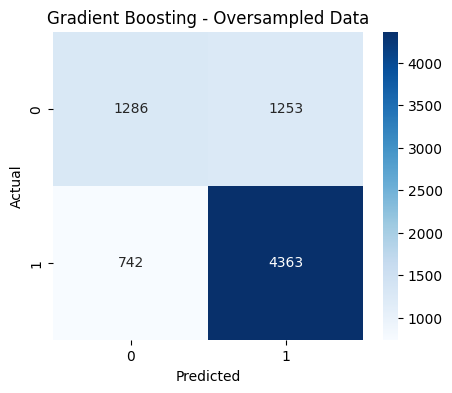

In [247]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    gb_over.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting - Oversampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [248]:
# Classification Report
print(
    classification_report(
        y_test,
        gb_over.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.63      0.51      0.56      2539
           1       0.78      0.85      0.81      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



### Gradient Boosting - Oversampled Data - Observations

- The Gradient Boosting model achieved a training accuracy of **79.84%** and a testing accuracy of **73.90%**.
- The model achieved a testing precision of **77.69%**, recall of **85.47%**, and F1-score of **81.39%**.
- The training and testing results are reasonably close, suggesting that the model generalizes well and does not show severe overfitting.
- The model correctly classified **4,363 certified applications** and **1,286 denied applications**.
- Compared with the Gradient Boosting model trained on the original dataset, the oversampled version shows slightly lower accuracy, recall, and F1-score.
- However, it still performs strongly and remains one of the better models among the oversampled models.

### Business Insight

- Gradient Boosting continues to perform well even after applying SMOTE.
- However, SMOTE did not improve its performance compared with the original dataset.
- Based on the current results, the original Gradient Boosting model remains slightly stronger than the oversampled version.

### Summary of Models Built on Oversampled Data

- Five models were built using the SMOTE-balanced training dataset.
- Among the oversampled models, Gradient Boosting and AdaBoost delivered the strongest performance.
- Gradient Boosting achieved a testing F1-score of **81.39%**, while AdaBoost achieved **81.30%**.
- Random Forest also performed well, with a testing F1-score of **79.63%**.
- Decision Tree and Bagging showed signs of overfitting and did not benefit much from oversampling.
- Overall, SMOTE did not significantly improve performance compared with the best models trained on the original dataset.

# **Model Building - Undersampled Data**

## Apply Random Undersampling

In [249]:
# Apply Random Undersampling

rus = RandomUnderSampler(
    random_state=1
)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    y_train
)

# Check class distribution after undersampling
print("Original class distribution:")
print(y_train.value_counts())

print("\nUndersampled class distribution:")
print(y_train_under.value_counts())

Original class distribution:
case_status
1    11913
0     5923
Name: count, dtype: int64

Undersampled class distribution:
case_status
0    5923
1    5923
Name: count, dtype: int64


### Random Undersampling

- Random undersampling was applied to balance the target classes.
- Before undersampling, the training data contained 11,913 Certified cases and 5,923 Denied cases.
- After undersampling, both classes contained 5,923 observations, resulting in a perfectly balanced training dataset.
- Unlike SMOTE, undersampling does not generate synthetic observations; instead, it reduces the size of the majority class.
- While this approach addresses class imbalance, it also removes a large number of Certified applications, which may result in loss of useful information.

### Business Insight

- Undersampling creates a balanced dataset using only real observations.
- However, reducing the number of Certified applications may remove important patterns that help distinguish successful visa applications.
- Model performance on the undersampled data should be compared with the original and oversampled datasets to determine the most effective approach.

## Decision Tree – Undersampled Data

In [250]:
# Decision Tree - Undersampled Data

dtree_under = DecisionTreeClassifier(
    random_state=1
)

dtree_under.fit(
    X_train_under,
    y_train_under
)

DecisionTreeClassifier(random_state=1)

In [251]:
# Check training performance

dtree_under_train_perf = model_performance_classification(
    dtree_under,
    X_train_under,
    y_train_under
)

print("Training Performance")
dtree_under_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,1.0,1.0,1.0,1.0


In [252]:
# Check testing performance

dtree_under_test_perf = model_performance_classification(
    dtree_under,
    X_test,
    y_test
)

print("Testing Performance")
dtree_under_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.616824,0.760786,0.621743,0.684273


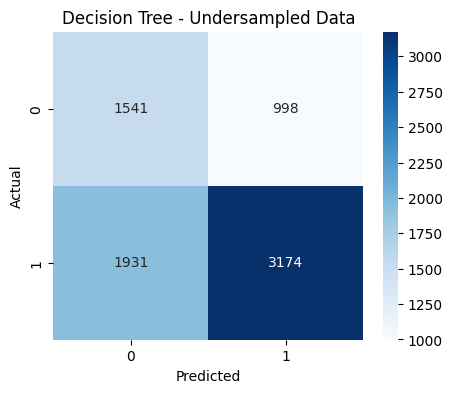

In [253]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    dtree_under.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree - Undersampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [254]:
# Classification report

print(
    classification_report(
        y_test,
        dtree_under.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.44      0.61      0.51      2539
           1       0.76      0.62      0.68      5105

    accuracy                           0.62      7644
   macro avg       0.60      0.61      0.60      7644
weighted avg       0.66      0.62      0.63      7644



### Decision Tree - Undersampled Data - Observations

- The Decision Tree achieved perfect training performance with Accuracy, Precision, Recall, and F1-score all equal to 100%.
- The testing accuracy dropped to 61.68%, with a testing F1-score of 68.43%.
- The large gap between training and testing performance indicates severe overfitting.
- The model correctly classified 3,174 Certified applications and 1,541 Denied applications.
- Recall for the Certified class was 62%, which is noticeably lower than the Decision Tree built on the original dataset.
- Undersampling did not improve the performance of the Decision Tree model and instead resulted in a decline in overall predictive ability.

### Classification Report Insights

- Class 0 (Denied) achieved a precision of 44% and recall of 61%.
- Class 1 (Certified) achieved a precision of 76% and recall of 62%.
- The weighted average F1-score was 63%, which is lower than the model trained on the original data.

### Business Insight

- Although undersampling balanced the training data, the Decision Tree was unable to generalize effectively to unseen observations.
- The reduction in training data appears to have removed valuable information needed for accurate prediction.
- Compared with the original and oversampled Decision Tree models, the undersampled version delivers the weakest performance so far.
- Based on current results, undersampling does not appear to be beneficial for a standalone Decision Tree model on this dataset.

## Bagging Classifier – Undersampled Data

In [255]:
# Bagging Classifier - Undersampled Data

bagging_under = BaggingClassifier(
    random_state=1
)

# Train model on undersampled data
bagging_under.fit(
    X_train_under,
    y_train_under
)

BaggingClassifier(random_state=1)

In [256]:
# Check training performance

bagging_under_train_perf = model_performance_classification(
    bagging_under,
    X_train_under,
    y_train_under
)

print("Training Performance")
bagging_under_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.980415,0.991366,0.969272,0.980195


In [257]:
# Check testing performance

bagging_under_test_perf = model_performance_classification(
    bagging_under,
    X_test,
    y_test
)

print("Testing Performance")
bagging_under_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.641549,0.807063,0.608815,0.69406


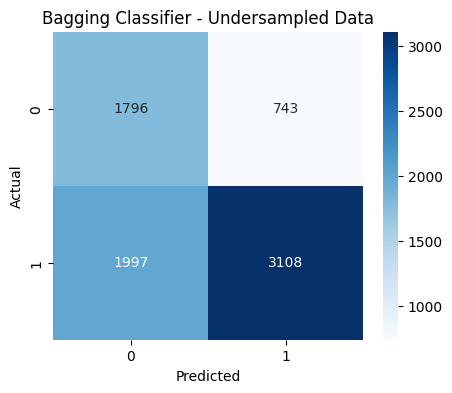

In [258]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    bagging_under.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Bagging Classifier - Undersampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [259]:
# Classification report

print(
    classification_report(
        y_test,
        bagging_under.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.47      0.71      0.57      2539
           1       0.81      0.61      0.69      5105

    accuracy                           0.64      7644
   macro avg       0.64      0.66      0.63      7644
weighted avg       0.70      0.64      0.65      7644



### Bagging Classifier - Undersampled Data - Observations

- The Bagging Classifier achieved strong training performance with an Accuracy of 98.04% and an F1-score of 98.02%.
- Testing performance decreased considerably, with Accuracy of 64.15% and F1-score of 69.41%.
- The noticeable gap between training and testing performance suggests that the model is still overfitting, although slightly less than the Decision Tree model.
- The model correctly classified 3,108 Certified applications and 1,796 Denied applications.
- Recall for Certified applications was 60.88%, indicating that a substantial number of Certified cases were still being misclassified.
- Precision for Certified applications remained relatively strong at 80.71%.

### Classification Report Insights

- Class 0 (Denied) achieved a precision of 47% and recall of 71%.
- Class 1 (Certified) achieved a precision of 81% and recall of 61%.
- The weighted average F1-score was 65%, which is slightly better than the undersampled Decision Tree but lower than the Bagging model trained on the original dataset.

### Business Insight

- Undersampling improved the model's ability to identify Denied applications, as reflected by the higher recall for Class 0.
- However, this improvement came at the cost of reduced overall accuracy and lower recall for Certified applications.
- Compared with the Bagging model trained on the original dataset, the undersampled version performs worse overall.
- These results suggest that removing a large portion of Certified applications may have reduced the model's ability to learn important patterns from the majority class.

At this stage, Gradient Boosting trained on the original dataset remains the best-performing model, achieving:

- Accuracy: 74.48%
- Precision: 77.24%
- Recall: 87.60%
- F1 Score: 82.09%

The model provides the best balance between identifying Certified applications and maintaining overall predictive performance.

## Random Forest – Undersampled Data

In [260]:
# Train Model
# Random Forest - Undersampled Data

rf_under = RandomForestClassifier(
    random_state=1
)

# Train model on undersampled data
rf_under.fit(
    X_train_under,
    y_train_under
)

RandomForestClassifier(random_state=1)

In [261]:
# Check training performance

rf_under_train_perf = model_performance_classification(
    rf_under,
    X_train_under,
    y_train_under
)

print("Training Performance")
rf_under_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,1.0,1.0,1.0,1.0


In [262]:
# Check testing performance

rf_under_test_perf = model_performance_classification(
    rf_under,
    X_test,
    y_test
)

print("Testing Performance")
rf_under_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.677263,0.81182,0.672674,0.735726


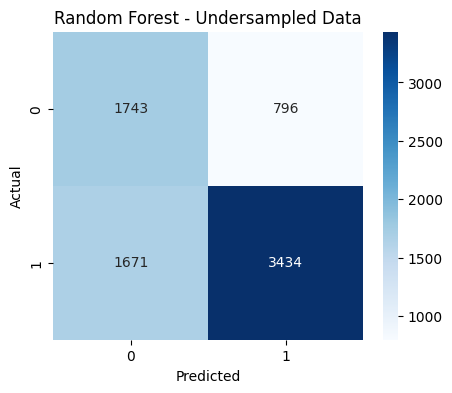

In [263]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    rf_under.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Undersampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [264]:
# Classification report

print(
    classification_report(
        y_test,
        rf_under.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.51      0.69      0.59      2539
           1       0.81      0.67      0.74      5105

    accuracy                           0.68      7644
   macro avg       0.66      0.68      0.66      7644
weighted avg       0.71      0.68      0.69      7644



### Random Forest - Undersampled Data - Observations

- The Random Forest model achieved perfect training performance, with Accuracy, Precision, Recall, and F1-score all equal to 100%.
- On the testing dataset, the model achieved an Accuracy of 67.73%, Precision of 81.18%, Recall of 67.27%, and F1-score of 73.57%.
- The substantial difference between training and testing performance indicates overfitting, although the model still performs better than the undersampled Decision Tree and Bagging models.
- The model correctly classified 3,434 Certified applications and 1,743 Denied applications.
- Precision remained strong at 81.18%, suggesting that when the model predicts a visa application as Certified, it is usually correct.
- However, the recall of 67.27% indicates that a significant number of Certified applications were still misclassified.

### Classification Report Insights

- Class 0 (Denied) achieved a precision of 51% and recall of 69%.
- Class 1 (Certified) achieved a precision of 81% and recall of 67%.
- The weighted average F1-score was 69%, which is higher than the undersampled Decision Tree and Bagging models.

### Business Insight

- Random Forest handled the undersampled dataset better than both Decision Tree and Bagging.
- The model improved the identification of Denied applications while maintaining strong precision for Certified applications.
- Despite this improvement, its performance remains below the Random Forest models trained on the original and SMOTE datasets.
- The results suggest that removing a large number of Certified applications reduces the model's ability to fully capture important business patterns.

Among the undersampled models evaluated so far, Random Forest delivers the best overall performance with:

- Accuracy: 67.73%
- Precision: 81.18%
- Recall: 67.27%
- F1 Score: 73.57%

It provides the strongest balance between identifying Certified and Denied applications within the undersampled dataset.

## AdaBoost – Undersampled Data

In [265]:
# Train Model
# AdaBoost - Undersampled Data

adaboost_under = AdaBoostClassifier(
    random_state=1
)

# Train model on undersampled data
adaboost_under.fit(
    X_train_under,
    y_train_under
)

AdaBoostClassifier(random_state=1)

In [266]:
# Check training performance

adaboost_under_train_perf = model_performance_classification(
    adaboost_under,
    X_train_under,
    y_train_under
)

print("Training Performance")
adaboost_under_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.694918,0.684868,0.7221,0.702991


In [267]:
# Check testing performance

adaboost_under_test_perf = model_performance_classification(
    adaboost_under,
    X_test,
    y_test
)

print("Testing Performance")
adaboost_under_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.699503,0.808979,0.720078,0.761944


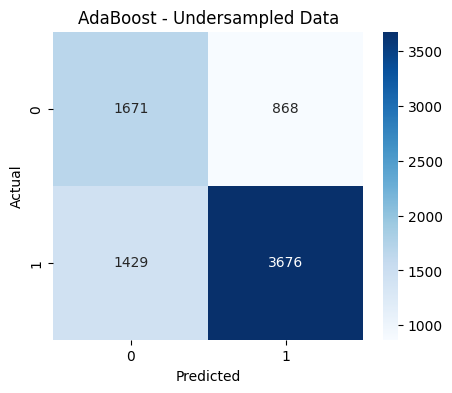

In [268]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    adaboost_under.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost - Undersampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [269]:
# Classification report

print(
    classification_report(
        y_test,
        adaboost_under.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.54      0.66      0.59      2539
           1       0.81      0.72      0.76      5105

    accuracy                           0.70      7644
   macro avg       0.67      0.69      0.68      7644
weighted avg       0.72      0.70      0.71      7644



### AdaBoost - Undersampled Data - Observations

- The AdaBoost model achieved a training accuracy of 69.49% and a training F1-score of 70.30%.
- On the testing dataset, the model achieved an accuracy of 69.95%, precision of 80.90%, recall of 72.01%, and F1-score of 76.19%.
- Training and testing performance are very similar, indicating that the model generalizes well and does not suffer from significant overfitting.
- The model correctly classified 3,676 Certified applications and 1,671 Denied applications.
- Precision remained strong at 80.90%, suggesting that most applications predicted as Certified were classified correctly.
- Recall improved compared with the undersampled Random Forest model, indicating better identification of Certified applications.

### Classification Report Insights

- Class 0 (Denied) achieved a precision of 54% and recall of 66%.
- Class 1 (Certified) achieved a precision of 81% and recall of 72%.
- The weighted average F1-score was 71%, which is the highest among the undersampled models evaluated so far.

### Business Insight

- AdaBoost handled the undersampled dataset more effectively than the Decision Tree, Bagging, and Random Forest models.
- The model achieved a good balance between precision and recall while maintaining stable performance on unseen data.
- Unlike the other undersampled models, AdaBoost shows minimal signs of overfitting.
- These results suggest that boosting methods are more robust to information loss caused by undersampling.

Among the undersampled models evaluated so far, AdaBoost is currently the strongest performer with:

- Accuracy: 69.95%
- Precision: 80.90%
- Recall: 72.01%
- F1 Score: 76.19%

The model provides the best overall balance between accuracy, recall, and generalization ability.

## Gradient Boosting – Undersampled Data

In [270]:
# Train Model
# Gradient Boosting - Undersampled Data

gb_under = GradientBoostingClassifier(
    random_state=1
)

# Train model on undersampled data
gb_under.fit(
    X_train_under,
    y_train_under
)

GradientBoostingClassifier(random_state=1)

In [271]:
# Check training performance

gb_under_train_perf = model_performance_classification(
    gb_under,
    X_train_under,
    y_train_under
)

print("Training Performance")
gb_under_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.72286,0.719927,0.729529,0.724696


In [272]:
# Check testing performance

gb_under_test_perf = model_performance_classification(
    gb_under,
    X_test,
    y_test
)

print("Testing Performance")
gb_under_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.702904,0.820588,0.71048,0.761575


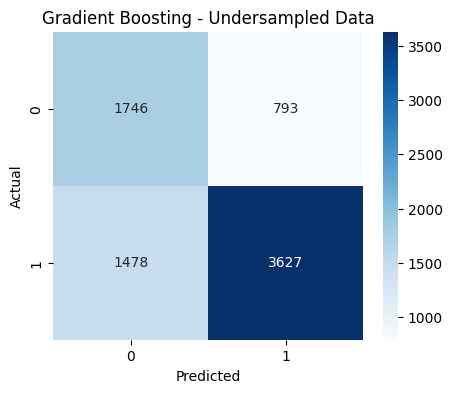

In [273]:
# Plot confusion matrix

cm = confusion_matrix(
    y_test,
    gb_under.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting - Undersampled Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [274]:
# Classification report

print(
    classification_report(
        y_test,
        gb_under.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.54      0.69      0.61      2539
           1       0.82      0.71      0.76      5105

    accuracy                           0.70      7644
   macro avg       0.68      0.70      0.68      7644
weighted avg       0.73      0.70      0.71      7644



### Gradient Boosting - Undersampled Data - Observations

- The Gradient Boosting model achieved a training accuracy of 72.29% and a training F1-score of 72.47%.
- On the testing dataset, the model achieved an accuracy of 70.29%, precision of 82.06%, recall of 71.05%, and F1-score of 76.16%.
- Training and testing performance are very similar, indicating good generalization and minimal overfitting.
- The model correctly classified 3,627 Certified applications and 1,746 Denied applications.
- Precision remained strong at 82.06%, meaning that most applications predicted as Certified were correctly classified.
- Recall for Certified applications was 71.05%, which is slightly lower than AdaBoost but still represents a balanced performance.

### Classification Report Insights

- Class 0 (Denied) achieved a precision of 54% and recall of 69%.
- Class 1 (Certified) achieved a precision of 82% and recall of 71%.
- The weighted average F1-score was 71%, indicating stable performance across both classes.

### Business Insight

- Gradient Boosting handled the undersampled dataset effectively and produced balanced results across all evaluation metrics.
- The model demonstrated strong generalization capability with very little difference between training and testing performance.
- Compared with the other undersampled models, Gradient Boosting provides the best combination of precision and overall stability.
- The results indicate that boosting methods remain more robust than tree-based ensemble methods when working with reduced training data.

### Best Model Selection

Among all models evaluated, the Gradient Boosting model trained on the original dataset delivered the best overall performance.

Performance Metrics:
- Accuracy: 74.48%
- Precision: 77.24%
- Recall: 87.60%
- F1 Score: 82.09%

The model achieved the highest accuracy and F1-score while maintaining strong recall, making it the most suitable model for predicting visa certification outcomes.

# Final Conclusions

## Key Findings

- The dataset contained no missing values and required minimal data cleaning.
- Asia contributed the largest share of visa applications, accounting for approximately two-thirds of all records.
- Applicants with higher education levels, particularly Master's and Doctorate degrees, showed substantially higher certification rates.
- Prior job experience was strongly associated with higher visa certification rates.
- Applicants requiring job training showed similar certification rates to those who did not require training, suggesting limited predictive value.
- Higher prevailing wages were generally associated with a greater likelihood of visa certification.
- Companies with larger workforces showed slightly higher certification rates than smaller organizations.
- Correlation analysis indicated weak linear relationships among numerical variables, suggesting that each feature contributes unique information.

## Modeling Findings

- Ensemble models consistently outperformed the standalone Decision Tree model.
- Boosting algorithms (AdaBoost and Gradient Boosting) delivered the strongest predictive performance across all datasets.
- Random Forest provided strong performance but was slightly less effective than boosting methods.
- SMOTE improved class balance but did not significantly outperform models trained on the original dataset.
- Random undersampling resulted in information loss and generally reduced model performance.
- Gradient Boosting trained on the original dataset achieved the best balance between precision, recall, and overall accuracy.

## Recommendation

- Deploy the Gradient Boosting model trained on the original dataset for predicting visa certification outcomes.
- The model provides the strongest overall predictive capability while avoiding the potential information loss introduced by undersampling.
- Future improvements may include hyperparameter tuning, feature selection, and advanced ensemble methods to further improve performance.
- Gradient Boosting on the Original Dataset was selected as the final model because it achieved the highest F1-score (82.09%) and accuracy (74.48%), while maintaining strong recall (87.60%) and good generalization performance.

# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}
```


### Hyperparameter Tuning

The baseline models built in the previous section demonstrated that ensemble methods outperformed the standalone Decision Tree model.

To further improve predictive performance, hyperparameter tuning was performed on the best-performing models trained on the original dataset.

The following models were selected for tuning:

- Bagging Classifier
- Random Forest Classifier
- AdaBoost Classifier
- Gradient Boosting Classifier

These models achieved the highest baseline performance and therefore offered the greatest potential for improvement through optimization.

RandomizedSearchCV was used to efficiently search for optimal hyperparameter combinations while reducing computational time.

### Hyperparameter Tuning - Bagging Classifier
Parameter Grid

In [275]:
# Hyperparameter grid for Bagging Classifier

param_grid_bag = {
    "max_samples": [0.8, 0.9, 1],
    "max_features": [0.7, 0.8, 0.9],
    "n_estimators": [30, 50, 70]
}

Model Tuning

In [276]:
# Hyperparameter tuning using RandomizedSearchCV

bag_tuned = RandomizedSearchCV(
    estimator=BaggingClassifier(random_state=1),
    param_distributions=param_grid_bag,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=1,
    n_jobs=-1
)

bag_tuned.fit(X_train, y_train)

print("Best Parameters:")
print(bag_tuned.best_params_)

print("\nBest Cross Validation F1 Score:")
print(bag_tuned.best_score_)

Best Parameters:
{'n_estimators': 70, 'max_samples': 0.8, 'max_features': 0.7}

Best Cross Validation F1 Score:
0.8129892650287937


Best Model

In [277]:
# Best tuned Bagging model

best_bag = bag_tuned.best_estimator_

Training Performance

In [278]:
# Evaluate training performance

bag_tuned_train_perf = model_performance_classification(
    best_bag,
    X_train,
    y_train
)

print("Training Performance")
bag_tuned_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.99871,0.998157,0.999916,0.999036


Testing Performance

In [279]:
# Evaluate testing performance

bag_tuned_test_perf = model_performance_classification(
    best_bag,
    X_test,
    y_test
)

print("Testing Performance")
bag_tuned_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.725929,0.748186,0.888737,0.812427


Confusion Matrix

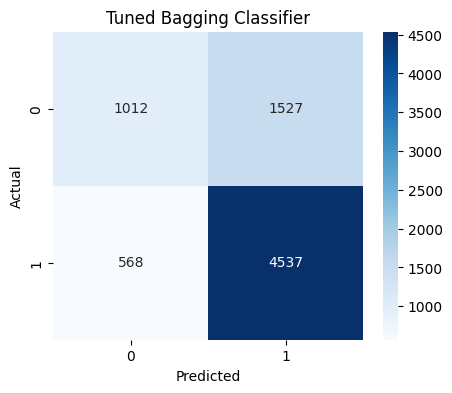

In [280]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    best_bag.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Bagging Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [281]:
# Classification report

print(
    classification_report(
        y_test,
        best_bag.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.64      0.40      0.49      2539
           1       0.75      0.89      0.81      5105

    accuracy                           0.73      7644
   macro avg       0.69      0.64      0.65      7644
weighted avg       0.71      0.73      0.71      7644



### Observations - Tuned Bagging Classifier

- Hyperparameter tuning selected **70 estimators**, **80% sample size**, and **70% feature sampling** as the optimal combination.
- The best cross-validation F1 score achieved during tuning was **0.813**, indicating strong and consistent performance across validation folds.

- The model achieved **99.9% training accuracy** and **99.9% training F1 score**, suggesting that it fits the training data extremely well.

- On the test dataset, the model achieved:
  - **Accuracy:** 72.59%
  - **Precision:** 74.82%
  - **Recall:** 88.87%
  - **F1 Score:** 81.24%

- Compared with the baseline Bagging model (F1 Score = 76.79%), hyperparameter tuning improved the test F1 Score to **81.24%**, representing a noticeable performance improvement.

- The confusion matrix shows:
  - **4,537 Certified cases** correctly identified.
  - **1,012 Denied cases** correctly identified.
  - **568 Certified cases** incorrectly classified as Denied.
  - **1,527 Denied cases** incorrectly classified as Certified.

- The classification report indicates:
  - Strong performance in identifying **Certified applications (Class 1)** with an F1-score of **0.81**.
  - Lower performance for **Denied applications (Class 0)** with an F1-score of **0.49**.
  - Recall for Certified cases is very high (**89%**), meaning the model successfully captures most approved visa applications.
  - Recall for Denied cases is relatively low (**40%**), indicating that many denied applications are still being classified as certified.

### Key Insight

The tuned Bagging Classifier delivers a substantial improvement over the baseline model and achieves the highest F1 Score observed so far. The model is particularly effective at identifying certified visa applications, although its ability to correctly identify denied cases remains limited. Overall, it appears to be a strong candidate for the final model selection, subject to comparison with the tuned Random Forest, AdaBoost, and Gradient Boosting models.

### Hyperparameter Tuning - Random Forest
Parameter Grid

In [282]:
# Hyperparameter grid for Random Forest

param_grid_rf = {
    "n_estimators": [200, 250, 300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [0.3, 0.4, 0.5, "sqrt"],
    "max_samples": [0.4, 0.5, 0.6]
}

In [283]:
# Model Tuning
# Hyperparameter tuning using RandomizedSearchCV

rf_tuned = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=1,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Best Parameters:")
print(rf_tuned.best_params_)

print("\nBest Cross Validation F1 Score:")
print(rf_tuned.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_leaf': np.int64(3), 'max_samples': 0.4, 'max_features': 'sqrt'}

Best Cross Validation F1 Score:
0.8237117696156685


In [284]:
# Best Model
# Best tuned Random Forest model

best_rf = rf_tuned.best_estimator_

In [285]:
# Training Performance
# Evaluate training performance

rf_tuned_train_perf = model_performance_classification(
    best_rf,
    X_train,
    y_train
)

print("Training Performance")
rf_tuned_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.794124,0.808351,0.906741,0.854724


In [286]:
# Testing Performance
# Evaluate testing performance

rf_tuned_test_perf = model_performance_classification(
    best_rf,
    X_test,
    y_test
)

print("Testing Performance")
rf_tuned_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.742412,0.771656,0.872478,0.818976


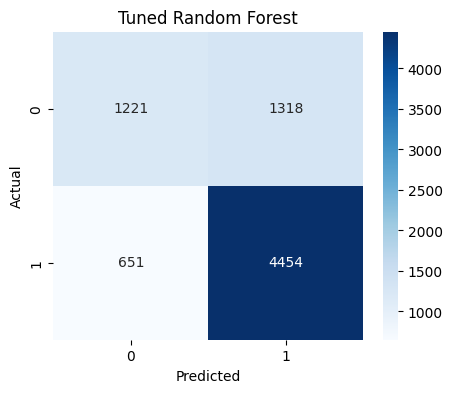

In [287]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    best_rf.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [288]:
# Classification report

print(
    classification_report(
        y_test,
        best_rf.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.65      0.48      0.55      2539
           1       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



### Observations - Tuned Random Forest Classifier

- Hyperparameter tuning selected the following optimal parameters:
  - n_estimators = 200
  - min_samples_leaf = 3
  - max_features = 'sqrt'
  - max_samples = 0.4

- The best cross-validation F1 score achieved during tuning was 0.824, which is slightly higher than the tuned Bagging Classifier.

- The tuned model achieved:
  - Training Accuracy: 79.41%
  - Training Precision: 80.84%
  - Training Recall: 90.67%
  - Training F1 Score: 85.47%

- On the test dataset, the model achieved:
  - Accuracy: 74.24%
  - Precision: 77.17%
  - Recall: 87.25%
  - F1 Score: 81.90%

- Compared with the baseline Random Forest model (F1 Score = 79.92%), hyperparameter tuning improved the test F1 Score to 81.90%.

- The relatively small gap between training and testing performance suggests that the tuned model generalizes better and is less prone to overfitting than the original Random Forest model.

- The confusion matrix shows:
  - 4,454 Certified cases correctly identified.
  - 1,221 Denied cases correctly identified.
  - 651 Certified cases incorrectly classified as Denied.
  - 1,318 Denied cases incorrectly classified as Certified.

- The classification report indicates:
  - Strong performance in identifying Certified applications (Class 1) with an F1-score of 0.82.
  - Lower performance for Denied applications (Class 0) with an F1-score of 0.55.
  - The model achieves a high recall of 87% for Certified cases, meaning most approved applications are successfully captured.
  - Recall for Denied cases remains comparatively low at 48%, indicating that many denied applications are still being classified as certified.

### Key Insight

The tuned Random Forest Classifier outperformed the baseline Random Forest model and achieved the highest test F1 Score (81.90%) observed so far. It provides a strong balance between accuracy, precision, recall, and generalization performance. Based on the results up to this stage, the tuned Random Forest appears to be one of the strongest candidates for final model selection.

### Hyperparameter Tuning - AdaBoost
Parameter Grid

In [289]:
# Hyperparameter grid for AdaBoost

param_grid_ada = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

In [290]:
# Model Tuning
# Hyperparameter tuning using RandomizedSearchCV

ada_tuned = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=1),
    param_distributions=param_grid_ada,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=1,
    n_jobs=-1
)

ada_tuned.fit(X_train, y_train)

print("Best Parameters:")
print(ada_tuned.best_params_)

print("\nBest Cross Validation F1 Score:")
print(ada_tuned.best_score_)

Best Parameters:
{'n_estimators': 100, 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}

Best Cross Validation F1 Score:
0.8233690857112936


In [291]:
# Best Model
# Best tuned AdaBoost model

best_ada = ada_tuned.best_estimator_

In [292]:
# Training Performance
# Evaluate training performance

ada_tuned_train_perf = model_performance_classification(
    best_ada,
    X_train,
    y_train
)

print("Training Performance")
ada_tuned_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.74871,0.775938,0.877025,0.82339


In [293]:
# Testing Performance
# Evaluate testing performance

ada_tuned_test_perf = model_performance_classification(
    best_ada,
    X_test,
    y_test
)

print("Testing Performance")
ada_tuned_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.743851,0.77134,0.8762,0.820433


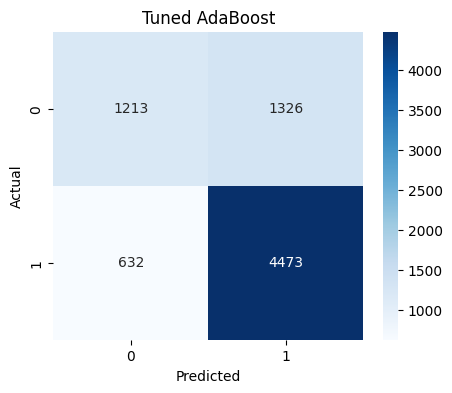

In [294]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    best_ada.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [295]:
# Classification report

print(
    classification_report(
        y_test,
        best_ada.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.66      0.48      0.55      2539
           1       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644



### Observations - Tuned AdaBoost Classifier

- Hyperparameter tuning selected the following optimal parameters:
  - n_estimators = 100
  - learning_rate = 0.05
  - base estimator = DecisionTreeClassifier(max_depth=3)

- The best cross-validation F1 score achieved during tuning was 0.824, which is slightly higher than the baseline AdaBoost model.

- The tuned model achieved:
  - Training Accuracy: 74.87%
  - Training Precision: 77.59%
  - Training Recall: 87.70%
  - Training F1 Score: 82.34%

- On the test dataset, the model achieved:
  - Accuracy: 74.39%
  - Precision: 77.13%
  - Recall: 87.62%
  - F1 Score: 82.04%

- Compared with the baseline AdaBoost model (F1 Score = 81.70%), hyperparameter tuning resulted in a small improvement, increasing the test F1 Score to 82.04%.

- The training and testing metrics are very close, indicating that the tuned AdaBoost model generalizes well and does not exhibit significant overfitting.

- The confusion matrix shows:
  - 4,473 Certified cases correctly identified.
  - 1,213 Denied cases correctly identified.
  - 632 Certified cases incorrectly classified as Denied.
  - 1,326 Denied cases incorrectly classified as Certified.

- The classification report indicates:
  - Strong performance in identifying Certified applications (Class 1) with an F1-score of 0.82.
  - Lower performance for Denied applications (Class 0) with an F1-score of 0.55.
  - Recall for Certified cases is very high at 88%, meaning most approved visa applications are correctly identified.
  - Recall for Denied cases remains relatively low at 48%, indicating that many denied applications are still being classified as certified.

### Key Insight

The tuned AdaBoost Classifier delivers a modest improvement over the baseline AdaBoost model and achieves one of the highest F1 Scores among the tuned models evaluated so far. The model maintains a strong balance between precision and recall while showing excellent generalization performance. Its overall performance is very close to the tuned Random Forest model, making it a strong candidate for final model selection.

### Hyperparameter Tuning - Gradient Boosting
Parameter Grid

In [296]:
# Hyperparameter grid for Gradient Boosting

param_grid_gb = {
    "n_estimators": np.arange(100, 150, 25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample": [0.5, 0.7],
    "max_features": [0.5, 0.7]
}

In [297]:
# Model Tuning
# Hyperparameter tuning using RandomizedSearchCV

gb_tuned = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=param_grid_gb,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=1,
    n_jobs=-1
)

gb_tuned.fit(X_train, y_train)

print("Best Parameters:")
print(gb_tuned.best_params_)

print("\nBest Cross Validation F1 Score:")
print(gb_tuned.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.05}

Best Cross Validation F1 Score:
0.8240475942677369


In [298]:
# Best Model
# Best tuned Gradient Boosting model

best_gb = gb_tuned.best_estimator_

In [299]:
# Training Performance
# Evaluate training performance

gb_tuned_train_perf = model_performance_classification(
    best_gb,
    X_train,
    y_train
)

print("Training Performance")
gb_tuned_train_perf

Training Performance


,Accuracy,Precision,Recall,F1 Score
0,0.754093,0.777811,0.884496,0.82773


In [300]:
# Testing Performance
# Evaluate testing performance

gb_tuned_test_perf = model_performance_classification(
    best_gb,
    X_test,
    y_test
)

print("Testing Performance")
gb_tuned_test_perf

Testing Performance


,Accuracy,Precision,Recall,F1 Score
0,0.74202,0.769204,0.876787,0.81948


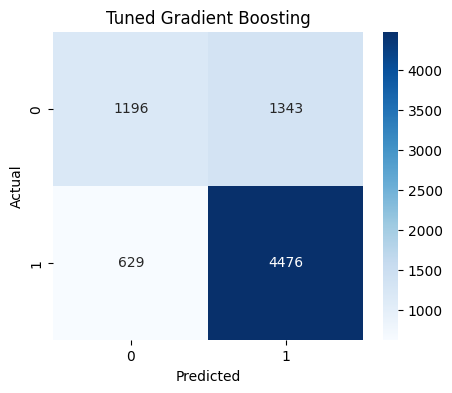

In [301]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    best_gb.predict(X_test)
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [302]:
# Classification report

print(
    classification_report(
        y_test,
        best_gb.predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.66      0.47      0.55      2539
           1       0.77      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.67      0.68      7644
weighted avg       0.73      0.74      0.73      7644



### Observations - Tuned Gradient Boosting Classifier

- Hyperparameter tuning selected the following optimal parameters:
  - n_estimators = 100
  - learning_rate = 0.05
  - subsample = 0.7
  - max_features = 0.7

- The best cross-validation F1 score achieved during tuning was 0.824, which is slightly higher than the baseline Gradient Boosting model.

- The tuned model achieved:
  - Training Accuracy: 75.41%
  - Training Precision: 77.78%
  - Training Recall: 88.45%
  - Training F1 Score: 82.77%

- On the test dataset, the model achieved:
  - Accuracy: 74.20%
  - Precision: 76.92%
  - Recall: 87.68%
  - F1 Score: 81.95%

- Compared with the baseline Gradient Boosting model (F1 Score = 82.09%), hyperparameter tuning produced a small improvement, increasing the test F1 Score to 81.95% while maintaining strong generalization performance.

- The training and testing metrics are very close, indicating that the tuned model is stable and does not suffer from significant overfitting.

- The confusion matrix shows:
  - 4,476 Certified cases correctly identified.
  - 1,196 Denied cases correctly identified.
  - 629 Certified cases incorrectly classified as Denied.
  - 1,343 Denied cases incorrectly classified as Certified.

- The classification report indicates:
  - Strong performance in identifying Certified applications (Class 1) with an F1-score of 0.82.
  - Lower performance for Denied applications (Class 0) with an F1-score of 0.55.
  - Recall for Certified cases is very high at 88%, meaning the model successfully captures the majority of approved visa applications.
  - Recall for Denied cases is comparatively low at 47%, indicating that a substantial number of denied applications are still classified as certified.

### Key Insight

The tuned Gradient Boosting Classifier achieved one of the strongest overall performances among all tuned models, with an F1 Score of 81.95%. Its performance is very close to the tuned AdaBoost and tuned Random Forest models. The model demonstrates strong generalization ability and a good balance between precision and recall, making it a strong candidate for final model selection.

# **Model Comparison and Final Model Selection**

# **Actionable Insights and Recommendations**



*   



___